# Figure 1
Figure 1: 
a) Schematic of the task
b) Train loss vs. # of parameters for GPT for Zipfian distribution
c) Max learned rank vs. params


## 1a: Visualize sequences

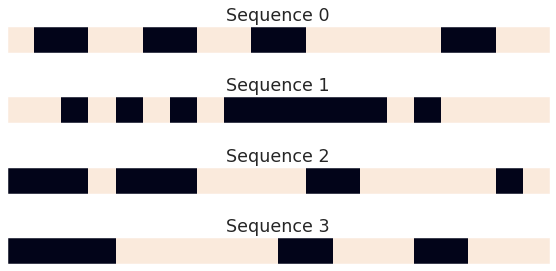

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import utils
import os
from collections import defaultdict
sns.set(
    context='talk', 
font_scale=1.0,
# font = "Arial",
color_codes=True, 
palette='deep',
#  style='ticks', 
 rc={"patch.edgecolor": "none", 
 'mathtext.fontset': 'cm', 
 'xtick.direction': 'in',
 'ytick.direction': 'in', 
 'axes.linewidth': 1.5, 
 'figure.dpi':70, 
'text.usetex':False , 
'font.size':24}
)
fig, axs = plt.subplots(4, 1, figsize=(10, 5))
# no ticks 
for i, ax in enumerate(axs):
    ax.imshow(np.random.choice([0, 1], size=(1, 20)))
    ax.set_title(f"Sequence {i}")
    ax.set_xticks([])
    ax.set_yticks([])
savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1a_sequences_visualization"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


## 1b & 1c: Visualize Zipf distribution

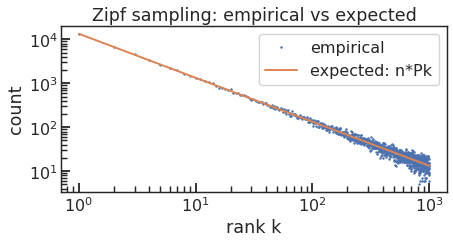

In [7]:
import numpy as np
import matplotlib.pyplot as plt
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})
K = 1000
Pk = 1.0 / np.arange(1, K+1)
Pk = Pk / Pk.sum()

n = 100000
samples = np.random.choice(np.arange(1, K+1), size=n, p=Pk)  # ranks 1..K
counts = np.bincount(samples, minlength=K+1)[1:]             # drop 0 bin

ranks = np.arange(1, K+1)
expected = n * Pk

mask = counts > 0  # avoid log(0)

plt.figure(figsize=(7,4))
plt.loglog(ranks[mask], counts[mask], '.', ms=3, label="empirical")
plt.loglog(ranks, expected, '-', lw=2, label="expected: n*Pk")
plt.xlabel("rank k")
plt.ylabel("count")
plt.title("Zipf sampling: empirical vs expected")
plt.legend()
plt.tight_layout()

savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1b_zipf_distribution"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


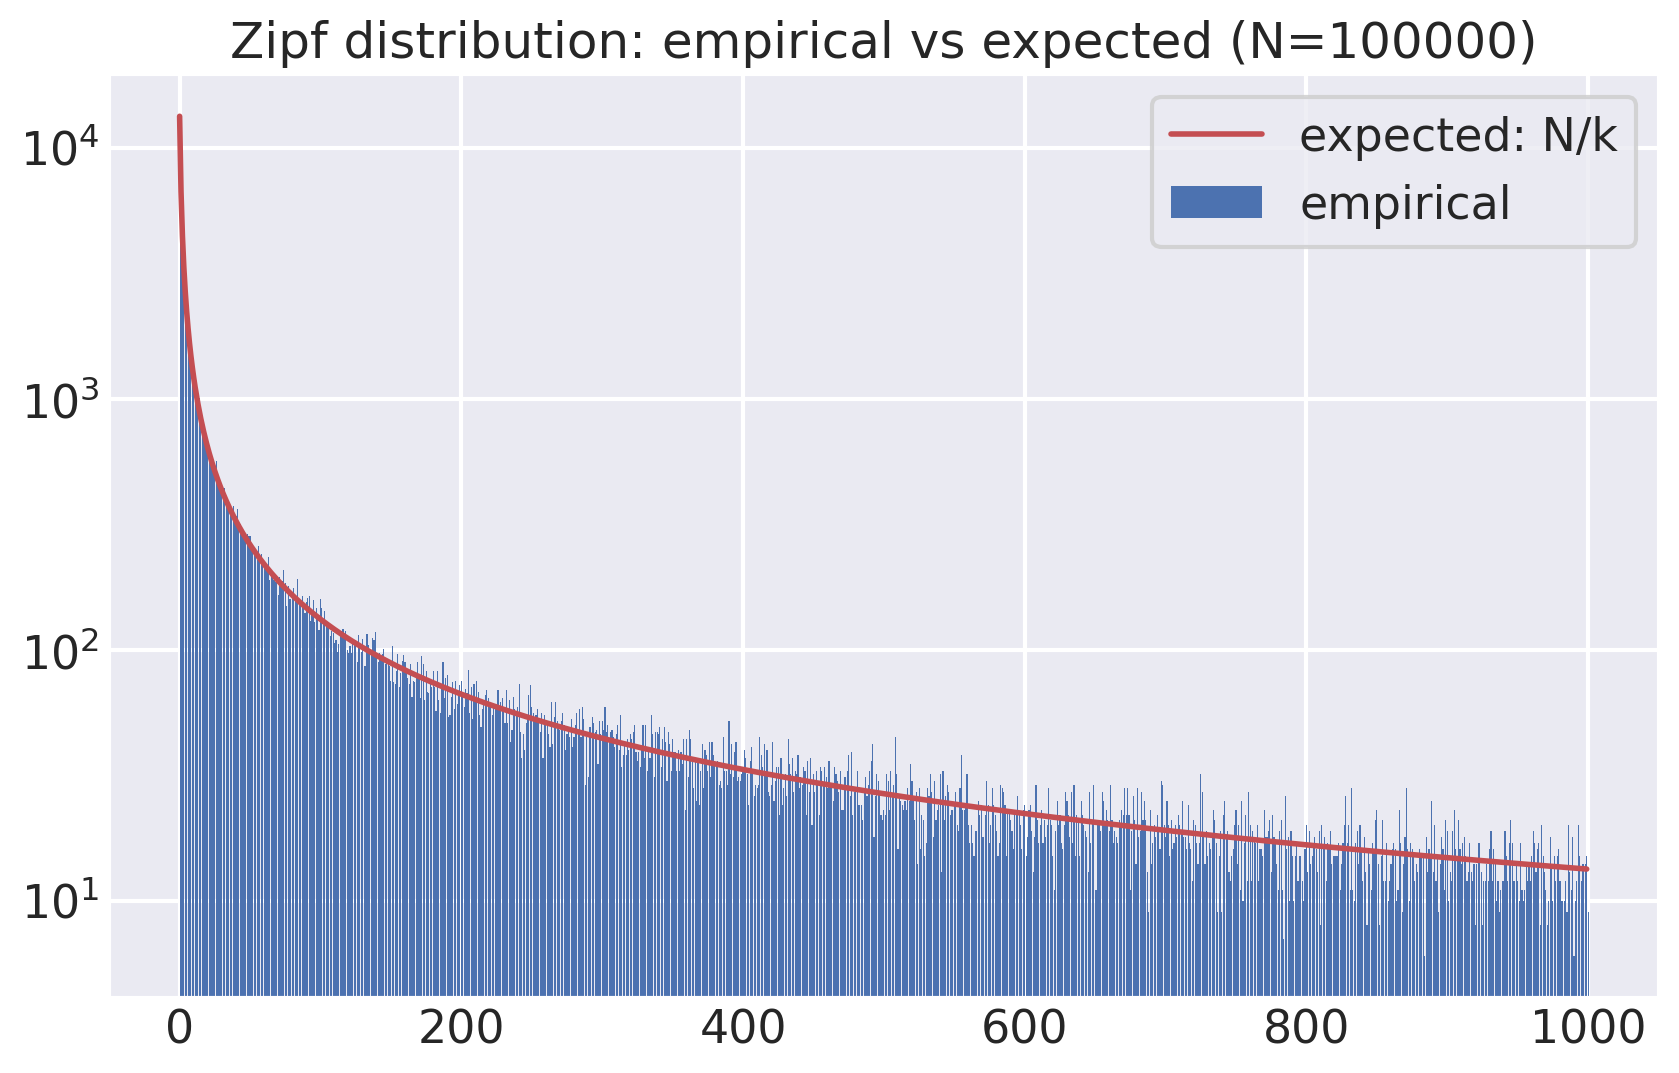

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# mpl.rcParams["patch.edgecolor"], mpl.rcParams.get("patch.force_edgecolor", None)
sns.set(
    context='talk', 
font_scale=1.0,
# font = "Arial",
color_codes=True, 
palette='deep',
#  style='ticks', 
 rc={"patch.edgecolor": "none", 
 'mathtext.fontset': 'cm', 
 'xtick.direction': 'in',
 'ytick.direction': 'in', 
 'axes.linewidth': 1.5, 
 'figure.dpi':70, 
'text.usetex':False , 
'font.size':24}
)
K = 1000
Pk = 1.0 / np.arange(1, K+1)
Pk = Pk / Pk.sum()

n = 100000
ranks = np.arange(1, K+1)

samples = np.random.choice(ranks, size=n, p=Pk)
counts = np.bincount(samples, minlength=K+1)[1:]   # counts for ranks 1..K  
expected = n * Pk
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)  # override the global rc dpi
ax.bar(np.arange(1,K+1), counts, label="empirical", color="C0")
ax.plot(np.arange(K), expected, "r", lw=2, label="expected: N/k")
ax.set_yscale("log")
plt.title("Zipf distribution: empirical vs expected (N=100000)")
ax.legend()
savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1c_zipf_distribution"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


## 1d: Train loss vs. # of parameters for GPT for Zipfian distribution, No resampling

In [12]:
import pickle 
from glob import glob 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import utils
from collections import defaultdict



In [13]:
folders = glob("/scratch/qanguyen/gautam/cache/memo_nov10_zipf_gpt2_vary_num_hidden_features_num_heads_noresample/*")
df = defaultdict(list)
for folder in folders:
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    if "logs" not in data:
        continue
    if len(data['logs']) < 80: 
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    # print("positional_encoding", data["positional_encoding"].shape)
    
    
    logs = data["logs"][0]
    train_losses = [l["train_loss"] for l in data["logs"]] 
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"]
    accuracy = data["logs"][-1]["test_metrics"]["accuracy"][:100].mean() 
    if num_parameters > 1e6 and train_losses[-1] > 0.3: 
        failed=True 
    else: 
        failed=False 
    # plt.imshow(np.corrcoef(data["positional_encoding"]),vmin=0)
    # plt.title(f"Corrcoef Positional Encoding for head {num_heads}, hidden features {num_hidden_features}")
    # plt.show()
    print("len(data['logs'])", len(data["logs"]), "arch", data["args"]["arch"], "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"], "accuracy", accuracy)
    df["train_loss"].extend(train_losses)
    df["test_accuracy"].extend([accuracy] * len(train_losses))
    df["num_parameters"].extend([num_parameters] * len(train_losses))
    df["num_hidden_features"].extend([num_hidden_features] * len(train_losses))
    df["num_heads"].extend([num_heads] * len(train_losses))
    df["epoch"].extend(range(len(train_losses)))
    df["failed"].extend([failed] * len(train_losses))
    # df = pd.read_csv(f"{folder}/eval_results.csv")
    # print(df.head())


len(data['logs']) 80 arch gpt num_parameters 155842 num_layers 12 num_heads 4 num_hidden_features 8 accuracy 0.7196971
len(data['logs']) 80 arch gpt num_parameters 3728322 num_layers 12 num_heads 10 num_hidden_features 16 accuracy 0.9548484
len(data['logs']) 80 arch gpt num_parameters 2392834 num_layers 12 num_heads 2 num_hidden_features 64 accuracy 0.50737375
len(data['logs']) 80 arch gpt num_parameters 9504258 num_layers 12 num_heads 8 num_hidden_features 32 accuracy 0.49979797
len(data['logs']) 80 arch gpt num_parameters 155842 num_layers 12 num_heads 8 num_hidden_features 4 accuracy 0.64666665
len(data['logs']) 80 arch gpt num_parameters 21334274 num_layers 12 num_heads 12 num_hidden_features 32 accuracy 0.50414145
len(data['logs']) 80 arch gpt num_parameters 1352258 num_layers 12 num_heads 6 num_hidden_features 16 accuracy 0.95181817
len(data['logs']) 80 arch gpt num_parameters 89234 num_layers 12 num_heads 12 num_hidden_features 2 accuracy 0.64909095
len(data['logs']) 80 arch gpt

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


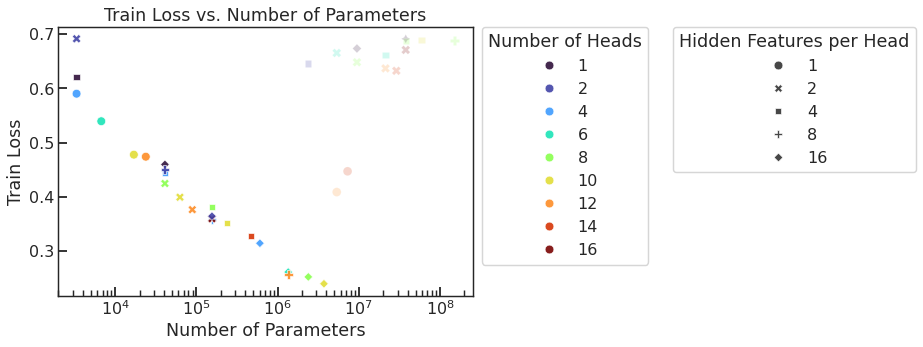

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


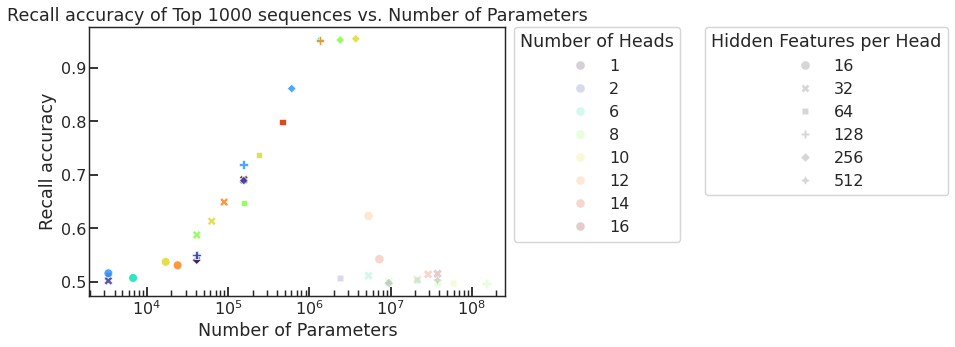

In [ ]:
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})

_df = pd.DataFrame(df)
_df = _df[_df["epoch"] == 79]
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
failed = _df[_df["failed"] == True]
ok = _df[_df["failed"] == False]

# more transparent (lower alpha) for failed
sns.scatterplot(
    data=failed,
    x="num_parameters", y="train_loss",
    hue="num_heads", style="num_hidden_features",
    palette="turbo",
    alpha=0.2,
    legend=False,
    ax=ax,
)

# less transparent for non-failed
sns.scatterplot(
    data=ok,
    x="num_parameters", y="train_loss",
    hue="num_heads", style="num_hidden_features",
    palette="turbo",
    alpha=0.9,
    legend="full",   # don't duplicate legend
    ax=ax,
)

ax.set_title("Train Loss vs. Number of Parameters")
ax.set_xlabel("Number of Parameters")
ax.set_xscale("log")
ax.set_ylabel("Train Loss")

# grab seaborn's combined legend entries, then remove it
handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

# split at the "num_hidden_features" header
i = labels.index("num_hidden_features")
h_hue, l_hue = handles[1:i], labels[1:i]
h_style, l_style = handles[i+1:], labels[i+1:]

# make room on the right for TWO legend boxes
fig.subplots_adjust(right=0.62)

# legend 1 (left of the pair)
leg1 = ax.legend(
    h_hue, l_hue,
    title="Number of Heads",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)
ax.add_artist(leg1)

# legend 2 (to the right of legend 1)
ax.legend(
    h_style, l_style,
    title="Hidden Features per Head",
    loc="upper left",
    bbox_to_anchor=(1.48, 1.0),  # increase x to move further right
    borderaxespad=0.0,
)
savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1d_zipf_distribution_train_loss_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.show()
 
# Show Recall accuracy vs num_heads and num_hidden_features
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# more transparent (lower alpha) for failed
sns.scatterplot(
    data=failed,
    x="num_parameters", y="test_accuracy",
    hue="num_heads", style="num_hidden_features",
    palette="turbo",
    alpha=0.2,
    legend="full",
    ax=ax,
)

# less transparent for non-failed
sns.scatterplot(
    data=ok,
    x="num_parameters", y="test_accuracy",
    hue="num_heads", style="num_hidden_features",
    palette="turbo",
    alpha=0.9,
    legend=False,   # don't duplicate legend
    ax=ax,
)

ax.set_title("Recall accuracy of Top 1000 sequences vs. Number of Parameters")
ax.set_xlabel("Number of Parameters")
ax.set_xscale("log")
ax.set_ylabel("Recall accuracy")

# grab seaborn's combined legend entries, then remove it
handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

# split at the "num_hidden_features" header
i = labels.index("num_hidden_features")
h_hue, l_hue = handles[1:i], labels[1:i]
h_style, l_style = handles[i+1:], labels[i+1:]

# make room on the right for TWO legend boxes
fig.subplots_adjust(right=0.62)

# legend 1 (left of the pair)
leg1 = ax.legend(
    h_hue, l_hue,
    title="Number of Heads",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)
ax.add_artist(leg1)

# legend 2 (to the right of legend 1)
ax.legend(
    h_style, l_style,
    title="Hidden Features per Head",
    loc="upper left",
    bbox_to_anchor=(1.48, 1.0),  # increase x to move further right
    borderaxespad=0.0,
)
savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1e_zipf_distribution_recall_accuracy_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
 

## S1a: Train loss vs. epoch / num heads / num hidden features

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


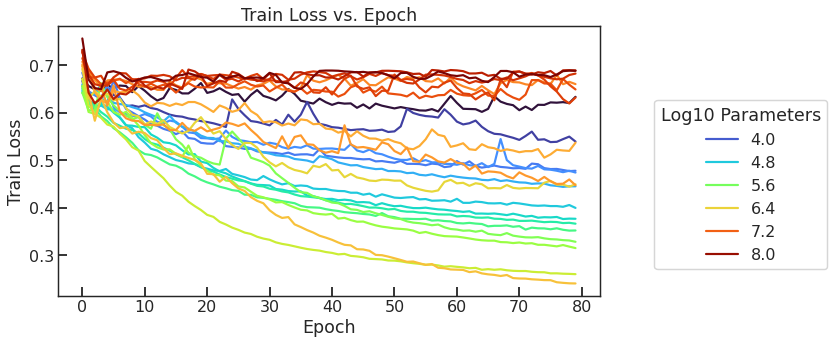

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


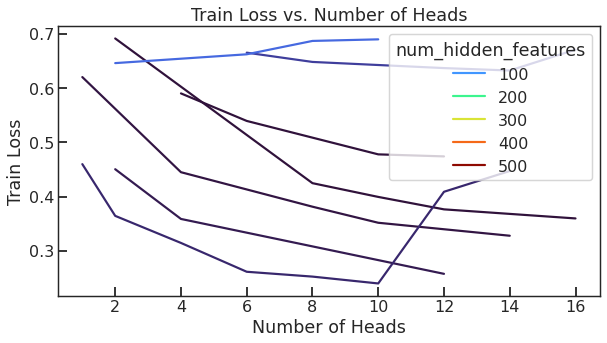

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


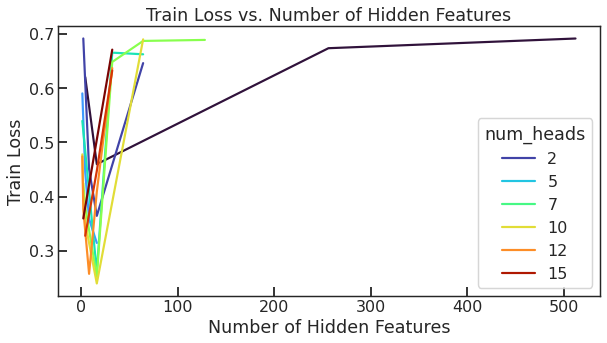

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


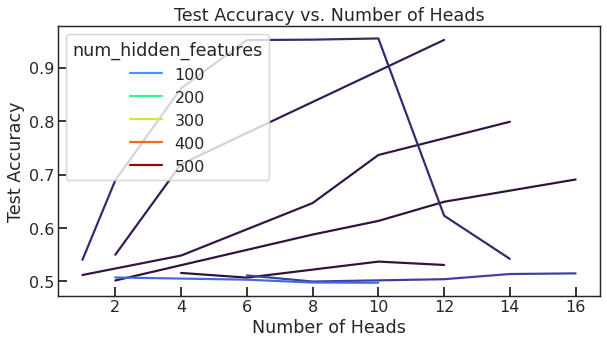

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


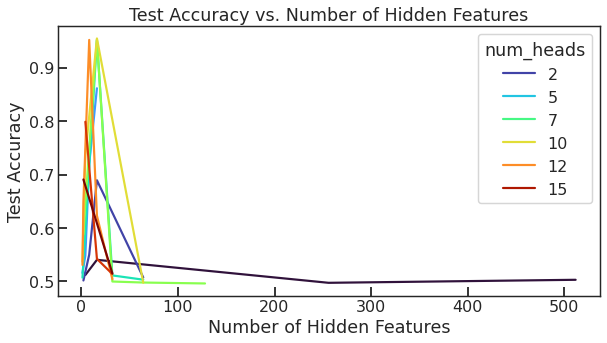

In [19]:

fig, ax = plt.subplots(1, 1, figsize=(10, 5)) 
df["log_num_parameters"] = np.log10(df["num_parameters"])
sns.lineplot(x="epoch", y="train_loss", data=df, hue="log_num_parameters", palette="turbo", errorbar=None)
plt.title(f"Train Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.legend(loc=(1.1,0.1), title="Log10 Parameters")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1a_train_loss_vs_epoch"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_heads", y="train_loss", hue = "num_hidden_features", data=_df, palette="turbo")
plt.title(f"Train Loss vs. Number of Heads")
plt.xlabel("Number of Heads")
# plt.xscale("log")
plt.ylabel("Train Loss")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1b_train_loss_vs_num_heads"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_hidden_features", y="train_loss", hue="num_heads", data=_df, palette="turbo")
plt.title(f"Train Loss vs. Number of Hidden Features")
plt.xlabel("Number of Hidden Features")
# plt.xscale("log")
plt.ylabel("Train Loss")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1c_train_loss_vs_num_hidden_features"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Test accuracy 
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_heads", y="test_accuracy", hue = "num_hidden_features", data=_df, palette="turbo")
plt.title(f"Test Accuracy vs. Number of Heads")
plt.xlabel("Number of Heads")
# plt.xscale("log")
plt.ylabel("Test Accuracy")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1d_test_accuracy_vs_num_heads"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_hidden_features", y="test_accuracy", hue="num_heads", data=_df, palette="turbo")
plt.title(f"Test Accuracy vs. Number of Hidden Features")
plt.xlabel("Number of Hidden Features")
# plt.xscale("log")
plt.ylabel("Test Accuracy")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1e_test_accuracy_vs_num_hidden_features"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show() 


## S2: Train loss vs. # of parameters for GPT for uniform distribution


In [1]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import utils
from collections import defaultdict
from glob import glob
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})

# fname = './cache/memo_may10_zipf_onelayerattention_lr_1e-3/memo_may10_zipf_onelayerattention_lr_1e-3_transformer_K_1000_L_100_hidden_8_nheads_20_nlayers_4_1746999806.3694336/memo_may10_zipf_onelayerattention_lr_1e-3_transformer_K_1000_L_100_hidden_8_nheads_20_nlayers_4_1746999806.3694336.pkl' 
# f = './cache/memo_june28_fork_progress/*'
f = '/scratch/qanguyen/gautam/cache/memo_jan14_uniformdist_modelsize/*'
df = defaultdict(list)
folders = glob(f) 
print(len(folders))
for folder in folders:
    
    subdir = folder.split('/')[-1]
    fname = folder + '/' + subdir + '.pkl'
    try:
        with open(fname, 
                'rb') as f:
            data = utils.CPU_Unpickler(f).load()
        
    except Exception as e:
        continue
    print("args", data["args"])
    print(data.keys())
    # plot train loss
    # fig, axs = plt.subplots(1, 1, figsize=(5, 6))
    # num_iters_per_epoch = 1000
    # axs.plot(np.arange(0,len(data["logs"])*num_iters_per_epoch,num_iters_per_epoch), [i["train_loss"] for i in data["logs"]])

    # plt.plot([i["train_loss"] for i in data["logs"]])
    # plt.show()
    num_heads = data["args"]["num_heads"]
    num_layers = data["args"]["num_layers"]   
    num_parameters = np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in data["model"].items()])
    print("model", data["args"]["lr"], num_heads, num_layers,
            "K", data["args"]["K"],
          "len logs", len(data["logs"]), "epochs", (data["logs"][-1]["epoch"]+1)*50, 
          "is_resample_tasks", data["args"]["is_resample_tasks"]) 
    if len(data["logs"]) < 100: 
        continue 
    print("keys", data["logs"][-1].keys()) 
    train_losses = data["logs"][-1]["train_loss"] 
    test_accuracy = data["logs"][-1]["test_metrics"]["accuracy"].mean()
    
    df["num_heads"].append(int(num_heads))
    df["num_layers"].append(int(num_layers))
    df["num_parameters"].append(num_parameters)
    df["train_losses"].append(train_losses) 
    df["test_accuracy"].append(test_accuracy)

/tmp/ipykernel_2519023/1536201598.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


143
args {'data': './cache', 'cache': './cache', 'wandb_log': False, 'wandb_project': 'l2l', 'wandb_group_name': 'memo_jan14_uniformdist_modelsize', 'seed': 8815000, 'num_iters_per_epoch': 1000, 'num_iters': 100000, 'batch_size': 256, 'workers': 4, 'optimizer': 'Adam', 'lr': 0.001, 'momentum': 0.9, 'weight_decay': 0.0, 'arch': 'gpt', 'gpt_bias': 'True', 'is_initialize_attention_weights_to_zero': 'False', 'num_hidden_features': 8, 'num_layers': 4, 'num_heads': 1, 'num_mlp_layers': 3, 'len_context': 100, 'SLURM_ARRAY_TASK_ID': 36, 'no_cuda': False, 'K': 20000, 'sequence_sampling_distribution': 'uniform', 'is_resample_tasks': 'False', 'fileprefix': 'transformer', 'savedir': '/scratch/qanguyen/gautam', 'resume': None, 'vocab_size': 2}
dict_keys(['args', 'logs', 'model', 'positional_encoding', 'token_embedding'])
model 0.001 1 4 K 20000 len logs 100 epochs 5000 is_resample_tasks False
keys dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'tes

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


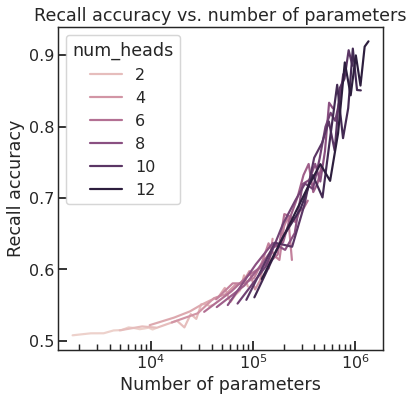

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


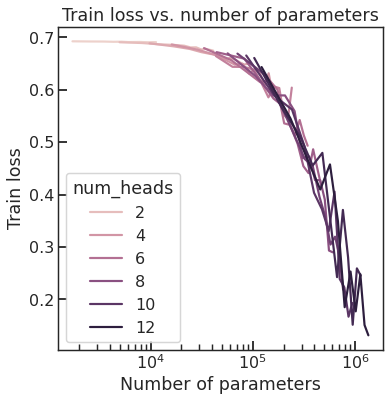

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6)) 
sns.lineplot(x="num_parameters", y="test_accuracy", hue="num_heads", data=df)
plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylabel("Recall accuracy")
plt.title("Recall accuracy vs. number of parameters")
savefigdir = "./figs/SupplementalFigure2"
out = f"{savefigdir}/S2a_recall_accuracy_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(6, 6)) 
sns.lineplot(x="num_parameters", y="train_losses", hue="num_heads", data=df)
plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylabel("Train loss")
plt.title("Train loss vs. number of parameters")
savefigdir = "./figs/SupplementalFigure2"
out = f"{savefigdir}/S2b_train_loss_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()






,num_heads,num_layers,num_parameters,train_losses,test_accuracy
0,1,4,4338,0.691503,0.514556
1,12,1,122018,0.643306,0.586596
2,4,10,130434,0.608120,0.615192
3,6,3,89906,0.632228,0.591606
4,9,12,765362,0.218673,0.873369
...,...,...,...,...,...
138,6,5,146450,0.617554,0.610768
139,12,6,681218,0.349283,0.790535
140,3,6,45890,0.666192,0.561111
141,8,1,56770,0.669508,0.550121


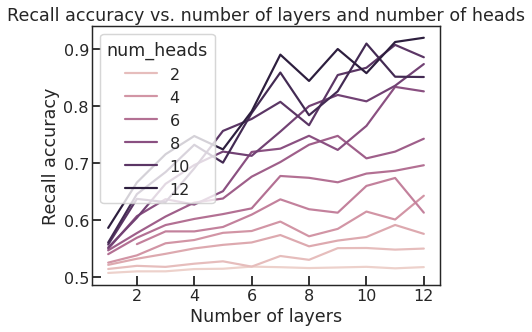

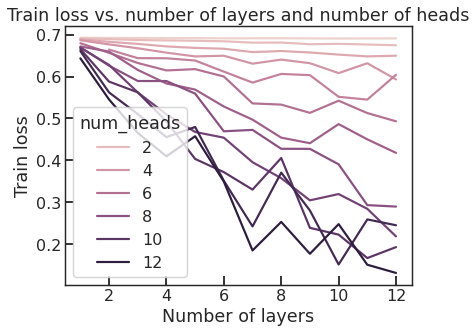

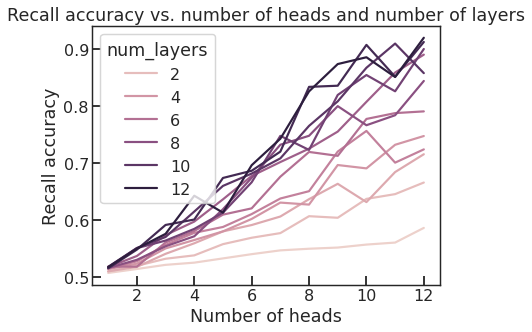

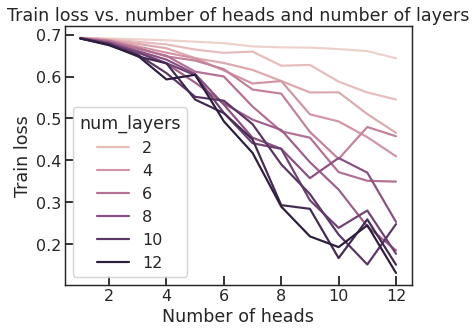

In [4]:
df = pd.DataFrame(df)
display(df)
sns.lineplot(x="num_layers", y="test_accuracy", hue="num_heads", data=df)
plt.xlabel("Number of layers")
plt.ylabel("Recall accuracy")
plt.title("Recall accuracy vs. number of layers and number of heads")
plt.show()
sns.lineplot(x="num_layers", y="train_losses", hue="num_heads", data=df)
plt.xlabel("Number of layers")
plt.ylabel("Train loss")
plt.title("Train loss vs. number of layers and number of heads")
plt.show()

sns.lineplot(x="num_heads", y="test_accuracy", hue="num_layers", data=df)
plt.xlabel("Number of heads")
plt.ylabel("Recall accuracy")
plt.title("Recall accuracy vs. number of heads and number of layers")
plt.show()
sns.lineplot(x="num_heads", y="train_losses", hue="num_layers", data=df)
plt.xlabel("Number of heads")
plt.ylabel("Train loss")
plt.title("Train loss vs. number of heads and number of layers")
plt.show()


# Figure 2

## 1 panel: appearances before saturation

In [1]:
import pickle 
from glob import glob 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import utils
from collections import defaultdict

sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})

/tmp/ipykernel_3197452/2178422424.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
from scipy.optimize import curve_fit

folders = glob("/scratch/qanguyen/gautam/cache/memo_nov10_zipf_gpt2_vary_num_hidden_features_num_heads_noresample/*")
df = defaultdict(list)
df_capacity = defaultdict(list)
# Reverse sigmoid (decreasing logistic): high -> low
def rev_sigmoid(x, y_low, y_high, x0, k):
    # k > 0; transition centered at x0
    return y_low + (y_high - y_low) / (1.0 + np.exp((x - x0) / k))

for folder in folders:
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    if "logs" not in data:
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    print("len(data['logs'])", len(data["logs"]), "key", data["logs"][0].keys(), "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"])
    if num_parameters > 1e6 and data["logs"][-1]["train_loss"] > 0.3:
        continue
    if len(data["logs"]) < 80:
        continue
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"] 
    num_appearances_at_39 = None
    for l in data["logs"]:
        num_appearances = l["num_apppearances"][::10]
        
        test_metrics = l["test_metrics"]
        sequence_ranks = test_metrics["sequence_rank"] * 10
        accuracy = test_metrics["accuracy"] 
        if num_appearances_at_39 is not None:
            num_appearances -= num_appearances_at_39
        df["num_appearances"].extend(num_appearances)
        df["sequence_rank"].extend(sequence_ranks)
        df["accuracy"].extend(accuracy)
        df["num_parameters"].extend([ num_parameters ] * len(num_appearances))
        df["epoch"].extend([l["epoch"]] * len(num_appearances))   
        switch_number = int (l["epoch"] // (np.round(len(data["logs"]) / 2.0))+1.0)
        df["switch_number"].extend([switch_number] * len(num_appearances))  
        if l["epoch"]  == 39: 
            num_appearances_at_39 = num_appearances
        if l["epoch"]  == 40:
            print(num_appearances[:30]) 
        if l["epoch"] >= 40: 
            assert switch_number > 1, "switch_number is not > 1"

len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 155842 num_layers 12 num_heads 4 num_hidden_features 8
[8152.  757.  383.  276.  195.  149.  136.  119.  106.   85.  101.   73.
   62.   59.   65.   48.   43.   59.   47.   45.   45.   42.   41.   40.
   26.   43.   26.   32.   36.   28.]
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 3728322 num_layers 12 num_heads 10 num_hidden_features 16
[8179.  776.  394.  279.  208.  149.  145.  123.   97.   88.   84.   56.
   66.   73.   59.   56.   57.   40.   46.   43.   32.   46.   35.   34.
   27.   34.   28.   20.   31.   24.]
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 2392834 num_layers 12 num_heads 2 num_hidden_features 

In [3]:
THRESHOLD = 0.9
_df = pd.DataFrame(df)
cols = ['num_appearances', 'sequence_rank', 'accuracy', 'num_parameters', 'epoch', 'num_appearances_at_saturation']
_results = []
df_capacity = defaultdict(list)
for switch_number in _df["switch_number"].unique():
    for num_parameter in _df["num_parameters"].unique():
        # Filter by parameter count
        subdf = _df[np.abs(_df["num_parameters"] - num_parameter) < 1e-2].copy()
        subdf = subdf[subdf["switch_number"] == switch_number]
        # display(subdf)
        
        # 1. Identify which ranks ever reached the threshold
        ranks_that_met_90 = subdf.loc[subdf["accuracy"] > THRESHOLD, "sequence_rank"].unique()
        
        # 2. Extract rows for ranks that met 90% (get the MIN epoch where accuracy > 0.9)
        df_met = (
            subdf[(subdf["sequence_rank"].isin(ranks_that_met_90)) & (subdf["accuracy"] > THRESHOLD)]
            .sort_values("epoch", ascending=True)
            .drop_duplicates("sequence_rank")
        )
        # df_met["num_appearances_at_saturation"] = df_met["num_appearances"]
        assert "switch_number" in df_met, "df_met doesn't have switch_number"
        df_capacity["num_parameters"].extend([num_parameter])
        df_capacity["max_rank_at_saturation"].extend([df_met["sequence_rank"].max()])
        # display("num_parameter", num_parameter, "df_met", df_met)
        # 3. Extract rows for ranks that NEVER met 90% (get the MAX epoch available)
        # df_never_met = (
        #     subdf[~subdf["sequence_rank"].isin(ranks_that_met_90)]
        #     .sort_values("epoch", ascending=False)
        #     .drop_duplicates("sequence_rank")
        # )
        # df_never_met["num_appearances_at_saturation"] = 1e5
        # 4. Combine and filter for requested columns
        result_epochs = (
            pd.concat([df_met])
            .sort_values("sequence_rank")
        )
        _results.append(result_epochs)

In [4]:
results = pd.concat(_results)

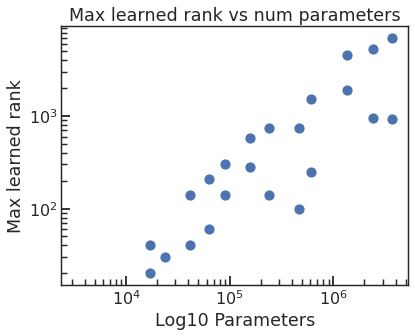

switch_number 1
switch_number 2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


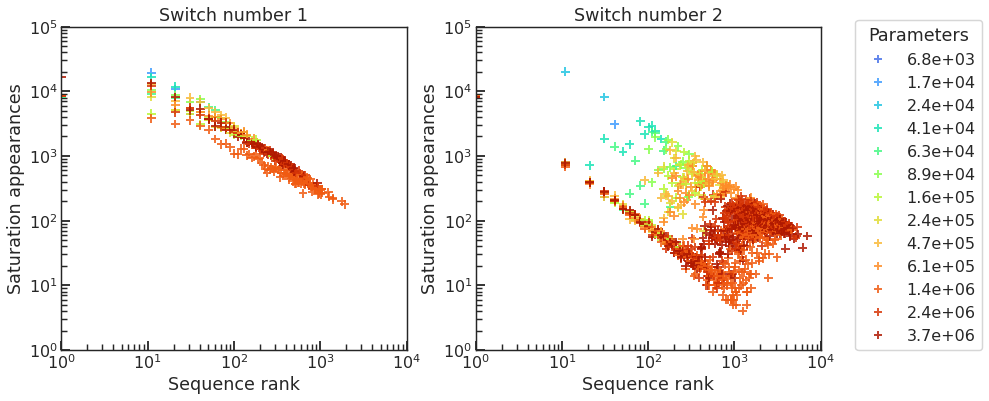

In [13]:
# plot the max rank at saturation vs num parameters
plt.scatter(df_capacity["num_parameters"], df_capacity["max_rank_at_saturation"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Log10 Parameters")
plt.ylabel("Max learned rank")
plt.title("Max learned rank vs num parameters")
plt.show()

# plot the saturation time vs sequence rank
def compute_saturation_time(row):
    time = row["epoch"] 
    if row["switch_number"] == 1:
        return time * 1000
    else:
        return (time - (row["switch_number"] - 1) * 40) * 1000

results["iters"] = results.apply(compute_saturation_time, axis=1)
results["sequence_rank_plus_one"] = results["sequence_rank"] + 1

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, switch_number in enumerate(results["switch_number"].unique()):
    subresults = results[results["switch_number"] == switch_number]
    order = np.sort(subresults["num_parameters"].unique())
    pal = sns.color_palette("turbo", n_colors=len(order)) 
    subresults.loc[:, "num_parameters"] = pd.to_numeric(subresults["num_parameters"])
    subresults.loc[:, "sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])

    subresults = subresults.sort_values(
        [ "sequence_rank_plus_one", "num_parameters"],
        ignore_index=True
    )
    print("switch_number", switch_number)
    # display(subresults)
    # pd.set_option('display.max_rows', 5000)
    sns.scatterplot(
        data=subresults,
        x="sequence_rank_plus_one",
        y="num_appearances",
        hue="num_parameters",
        hue_order=order,
        palette=pal,
        linewidth=2.0,
        alpha=0.85,
        legend=False if i == 0 else True,
        marker="+",
        ax=axs[i]
    )
    axs[i].set_title(f"Switch number {switch_number}")
    axs[i].set_xscale("log")
    axs[i].set_xlim(1, 10000)
    axs[i].set_ylim(1, 100000)
    axs[i].set_yscale("log")
    axs[i].set_xlabel("Sequence rank")
    axs[i].set_ylabel("Saturation appearances")

handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(
    handles=handles[1:],
    labels=[f"{float(l):.2g}" for l in labels[1:]],
    title="Parameters",
    loc=(1.1, 0.0),
)
savefigdir = "./figs/Figure2"
out = f"{savefigdir}/saturation_appearances_vs_sequence_rank_scatter"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()



## Supplementary Figure 3: Saturation iteration vs. rank

switch_number 1
switch_number 2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


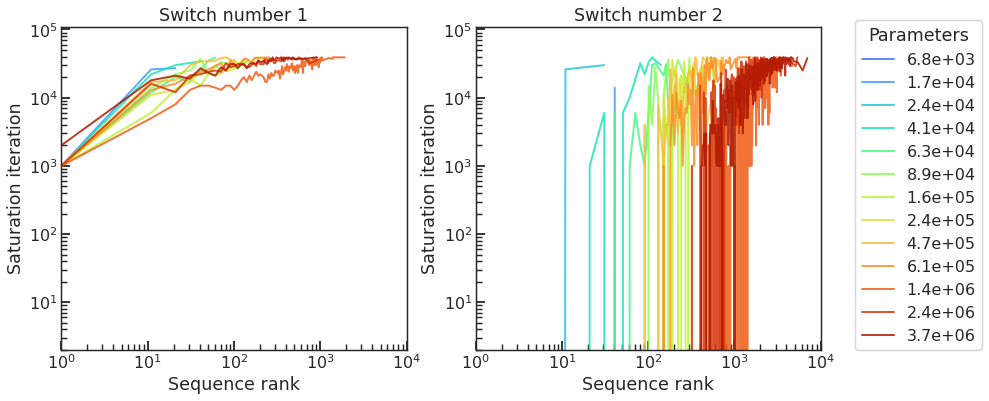

In [16]:

# 2 significant figures for legend labels
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, switch_number in enumerate(results["switch_number"].unique()):
    subresults = results[results["switch_number"] == switch_number] 
    print("switch_number", switch_number)
    order = np.sort(subresults["num_parameters"].unique())
    pal = sns.color_palette("turbo", n_colors=len(order))
    subresults.loc[:, "num_parameters"] = pd.to_numeric(subresults["num_parameters"])
    subresults.loc[:, "sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])

    sns.lineplot(
        data=subresults,
        x="sequence_rank_plus_one",
        y="iters",
        hue="num_parameters",           # <-- use formatted labels  
        hue_order=order,              # <-- numeric ascending -> consistent color order
        palette=pal,
        linewidth=2.0,
        alpha=0.85,
        legend=False if i == 0 else True,
        ax=axs[i]
    )
    axs[i].set_title(f"Switch number {switch_number}")
    axs[i].set_xscale("log")
    axs[i].set_xlim(1, 10000)
    axs[i].set_ylim(2, 110000)
    axs[i].set_yscale("log")
    axs[i].set_xlabel("Sequence rank")
    axs[i].set_ylabel("Saturation iteration")

handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(
    handles=handles[1:],
    labels=[f"{float(l):.2g}" for l in labels[1:]],
    title="Parameters",
    loc=(1.1, 0.0),
)
savefigdir = "./figs/SupplementalFigure3"
out = f"{savefigdir}/saturation_iterations_vs_sequence_rank"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


# Figure 3: Data switch experiments (3 panels)

In [1]:
import pickle 
from glob import glob 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import utils
from collections import defaultdict




/tmp/ipykernel_3220721/3798692806.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
folders = glob("/scratch/qanguyen/gautam/cache/memo_nov10_zipf_gpt2_vary_num_hidden_features_num_heads_doresample/*")
df = defaultdict(list)
for folder in folders:
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    if "logs" not in data:
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    print("len(data['logs'])", len(data["logs"]), "key", data["logs"][0].keys(), "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"])
    if num_parameters > 1e6 and data["logs"][-1]["train_loss"] > 0.3:
        continue
    if len(data["logs"]) < 10:
        continue
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"] 
    
    for l in data["logs"]:
        num_appearances = l["num_apppearances"][::10]
        test_metrics = l["test_metrics"]
        sequence_ranks = test_metrics["sequence_rank"] * 10
        accuracy = test_metrics["accuracy"] 
        df["num_appearances"].extend(num_appearances)
        df["sequence_rank"].extend(sequence_ranks)
        df["accuracy"].extend(accuracy)
        df["num_parameters"].extend([np.log10(num_parameters)] * len(num_appearances))
        df["epoch"].extend([l["epoch"]] * len(num_appearances))

len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 37882882 num_layers 12 num_heads 16 num_hidden_features 32
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 37882882 num_layers 12 num_heads 1 num_hidden_features 512
len(data['logs']) 1 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 11314 num_layers 12 num_heads 8 num_hidden_features 1
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 5358722 num_layers 12 num_heads 12 num_hidden_features 16
len(data['logs']) 1 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_paramete

In [3]:
_df = pd.DataFrame(df)
_df["num_parameters"] = 10**_df["num_parameters"]
display(_df)


,num_appearances,sequence_rank,accuracy,num_parameters,epoch
0,0.0,0,0.323232,11314.0,0
1,0.0,10,0.515152,11314.0,0
2,0.0,20,0.535354,11314.0,0
3,0.0,30,0.474747,11314.0,0
4,0.0,40,0.555556,11314.0,0
...,...,...,...,...,...
17599995,4.0,99950,0.474747,120234.0,79
17599996,4.0,99960,0.444444,120234.0,79
17599997,4.0,99970,0.494949,120234.0,79
17599998,6.0,99980,0.636364,120234.0,79


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


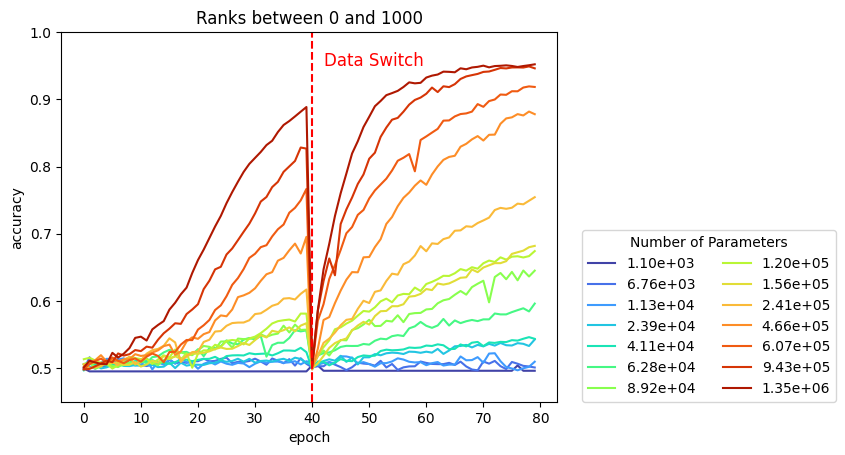

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


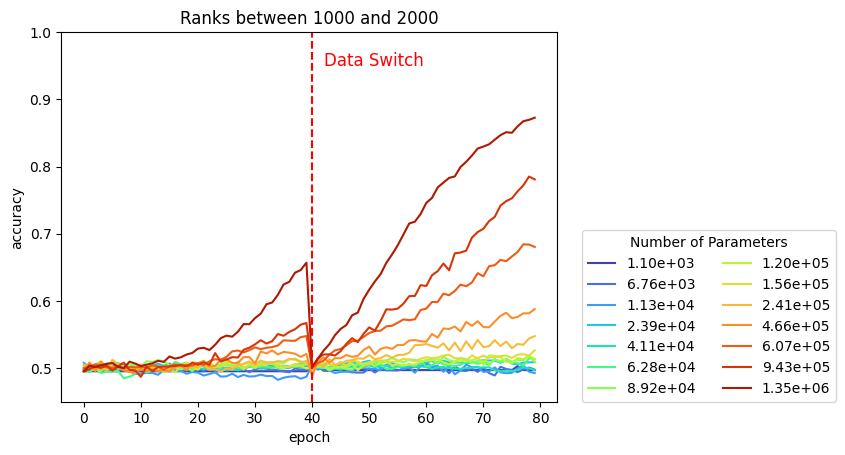

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


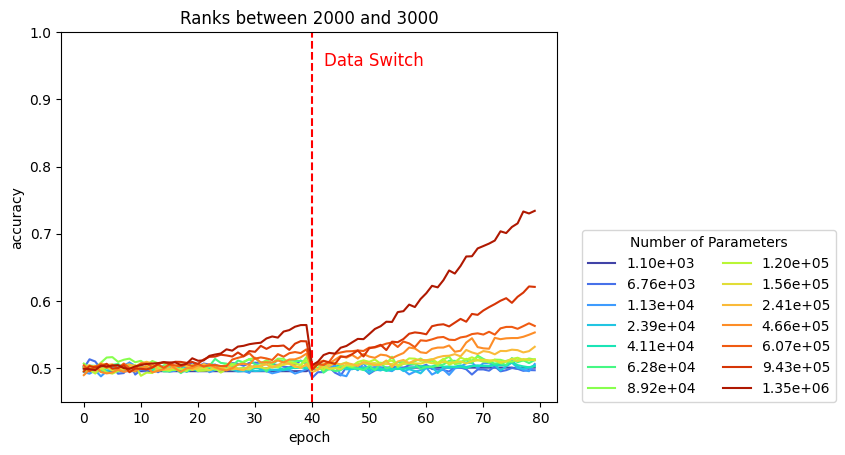

In [6]:

batch = 1000
order = np.sort(_df["num_parameters"].unique())
pal = sns.color_palette("turbo", n_colors=len(order))
for i in range(3):
    _df["num_parameters"] = _df["num_parameters"].astype(float)
    
    # 1. Capture the axis object from lineplot
    fig, ax = plt.subplots()
    sns.lineplot(
        data=_df[(_df['sequence_rank'] <= batch*(i+1)) & (_df['sequence_rank'] >= batch*i)], 
        x="epoch", y="accuracy", 
        hue="num_parameters", palette=pal, legend="full", errorbar=None,
        ax=ax
    ) 
    
    # 2. Get handles and current labels
    handles, labels = ax.get_legend_handles_labels()
    
    # 3. Format labels to 2 decimal places (handling the title label if it exists)
    

    formatted_labels = []
    for label in labels:
        try:
            formatted_labels.append(f"{float(label):.2e}")  # e.g. 1.35e+06
            # or: formatted_labels.append(f"{float(label):.2g}")  # 2 sig figs, auto
        except ValueError:
            formatted_labels.append(label)
    # 4. Re-apply the legend with formatted labels
    ax.legend(handles=handles, labels=formatted_labels, 
       title = "Number of Parameters", ncol=2, loc=(1.05, 0))
    ax.axvline(x=40, color='red', linestyle='--')
    ax.text(42, 0.95, "Data Switch", color='red', fontsize=12)
    ax.set_title(f"Ranks between {batch*i} and {batch*(i+1)}")
    ax.set_ylim(0.45, 1.0)
    savefigdir = "./figs/Figure3"
    out = f"{savefigdir}/data_switch_accuracy_vs_epoch_ranks_{batch*i}_{batch*(i+1)}"
    utils.ensure_dir(savefigdir)
    fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
    fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


## Supplementary Figure 4: Varying K data switch experiments

In [16]:
folders = glob("/scratch/qanguyen/gautam/cache/memo_mar24_zipf_onelayerattention_vary_num_hidden_features_num_heads_K/*")
df = defaultdict(list)
for folder in folders:
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    if "logs" not in data:
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    print("len(data['logs'])", len(data["logs"]), "key", data["logs"][0].keys(), "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"])
    if num_parameters > 1e6 and data["logs"][-1]["train_loss"] > 0.3:
        continue
    if len(data["logs"]) < 10:
        continue
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"] 
    
    for l in data["logs"]:
        num_appearances = l["num_apppearances"][::10]
        test_metrics = l["test_metrics"]
        sequence_ranks = test_metrics["sequence_rank"] * 10
        accuracy = test_metrics["accuracy"] 
        df["num_appearances"].extend(num_appearances)
        df["sequence_rank"].extend(sequence_ranks)
        df["accuracy"].extend(accuracy)
        df["num_parameters"].extend([ (num_parameters)] * len(num_appearances))
        df["epoch"].extend([l["epoch"]] * len(num_appearances))
        df["K"].extend([data["args"]["K"]] * len(num_appearances))

len(data['logs']) 1 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 157870082 num_layers 1 num_heads 10 num_hidden_features 512
len(data['logs']) 100 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 4682 num_layers 1 num_heads 10 num_hidden_features 2
len(data['logs']) 100 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 2234 num_layers 1 num_heads 6 num_hidden_features 2
len(data['logs']) 100 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 7898 num_layers 1 num_heads 14 num_hidden_features 2
len(data['logs']) 51 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 92851

In [19]:
_df = pd.DataFrame(df)
display(_df)


KeyboardInterrupt: 

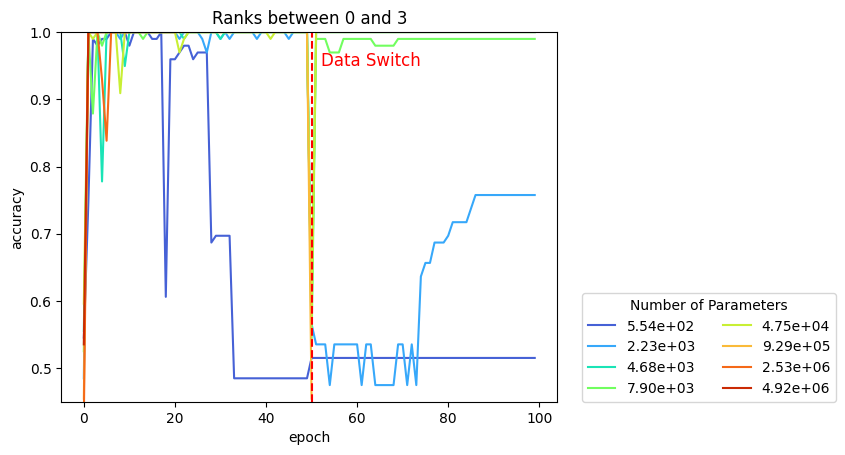

/tmp/ipykernel_3220721/1603074252.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/tmp/ipykernel_3220721/1603074252.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=handles, labels=formatted_labels,


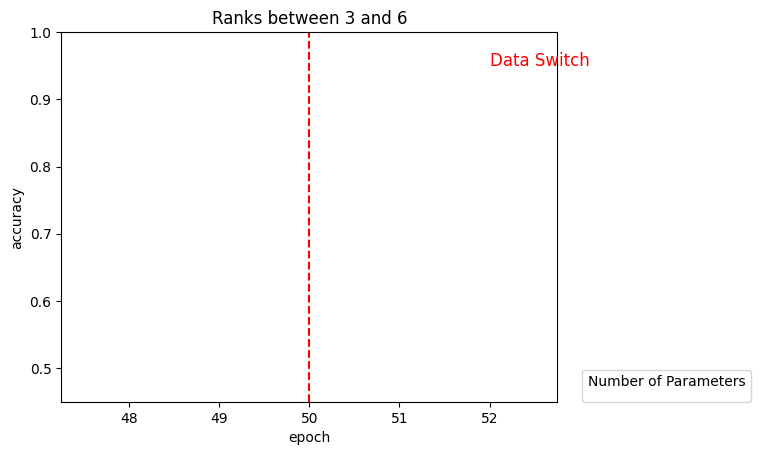

/tmp/ipykernel_3220721/1603074252.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/tmp/ipykernel_3220721/1603074252.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=handles, labels=formatted_labels,


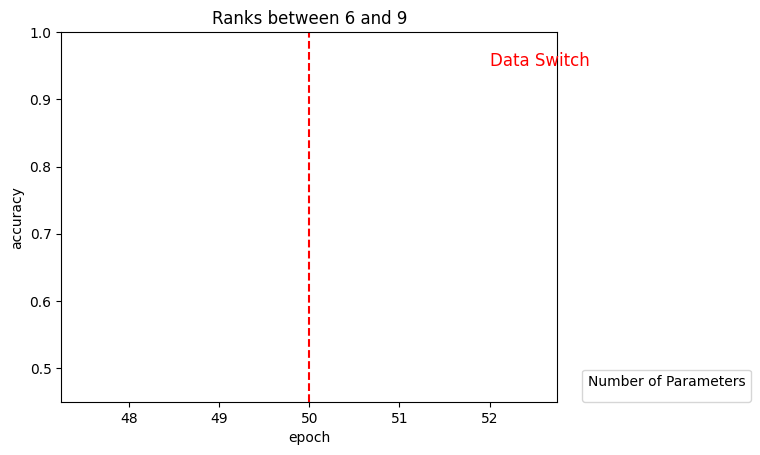

/tmp/ipykernel_3220721/1603074252.py:10: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  sns.lineplot(


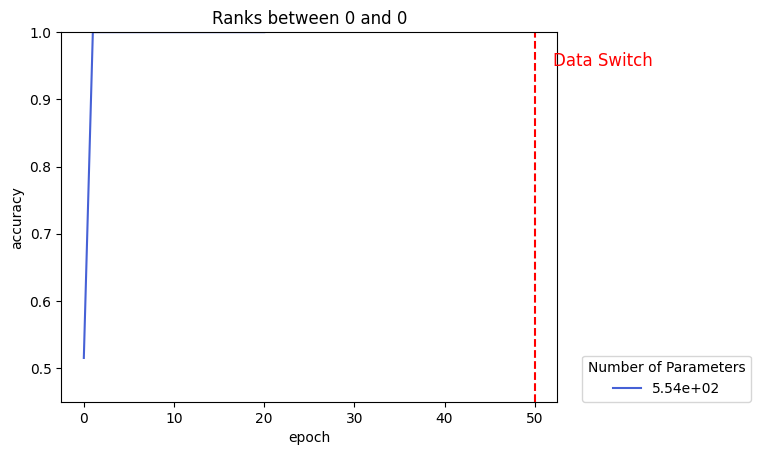

/tmp/ipykernel_3220721/1603074252.py:10: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  sns.lineplot(


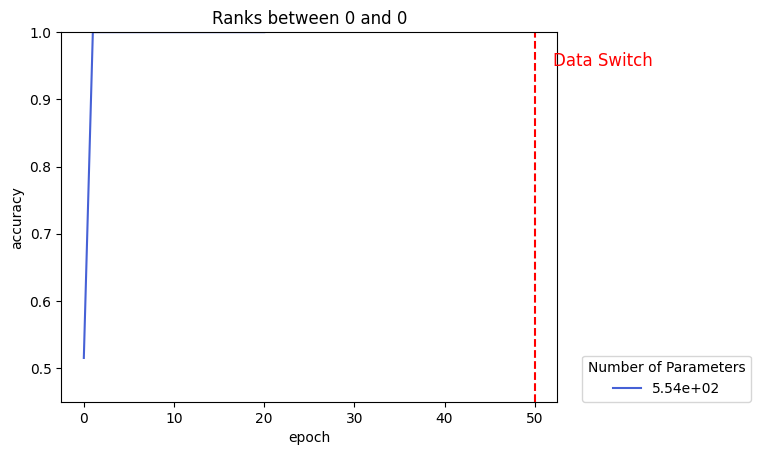

/tmp/ipykernel_3220721/1603074252.py:10: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  sns.lineplot(


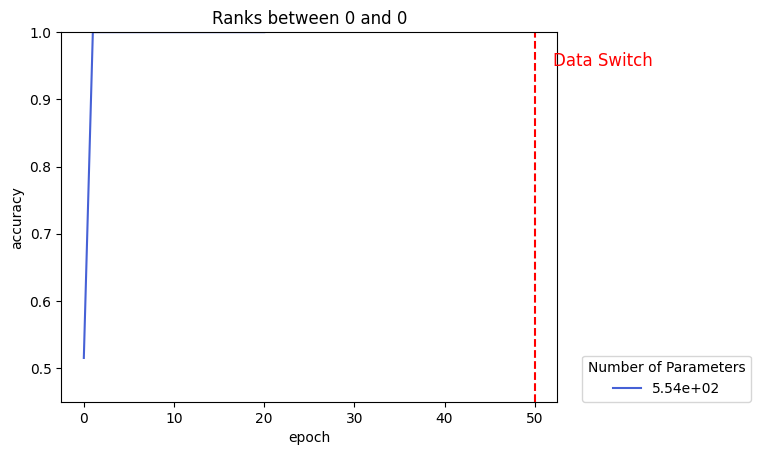

In [21]:
order = np.sort(_df["num_parameters"].unique())
pal = sns.color_palette("turbo", n_colors=len(order))
for K in _df["K"].unique():
    batch = K // 3
    for i in range(3):
        _df["num_parameters"] = _df["num_parameters"].astype(float)
        subdf = _df[_df["K"] == K]
        # 1. Capture the axis object from lineplot
        fig, ax = plt.subplots()
        sns.lineplot(
            data=subdf[(subdf['sequence_rank'] <= batch*(i+1)) & (subdf['sequence_rank'] >= batch*i)], 
            x="epoch", y="accuracy", 
            hue="num_parameters", palette=pal, legend="full", errorbar=None,
            ax=ax
        ) 
        
        # 2. Get handles and current labels
        handles, labels = ax.get_legend_handles_labels()
        
        # 3. Format labels to 2 decimal places (handling the title label if it exists)
        

        formatted_labels = []
        for label in labels:
            try:
                formatted_labels.append(f"{float(label):.2e}")  # e.g. 1.35e+06
                # or: formatted_labels.append(f"{float(label):.2g}")  # 2 sig figs, auto
            except ValueError:
                formatted_labels.append(label)
        # 4. Re-apply the legend with formatted labels
        ax.legend(handles=handles, labels=formatted_labels, 
        title = "Number of Parameters", ncol=2, loc=(1.05, 0))
        ax.axvline(x=50, color='red', linestyle='--')
        ax.text(52, 0.95, "Data Switch", color='red', fontsize=12)
        ax.set_title(f"Ranks between {batch*i} and {batch*(i+1)}")
        ax.set_ylim(0.45, 1.0)
        # savefigdir = "./figs/Figure3"
        # out = f"{savefigdir}/data_switch_accuracy_vs_epoch_ranks_{batch*i}_{batch*(i+1)}"
        # utils.ensure_dir(savefigdir)
        # fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
        # fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
        plt.show()


# Figure 4: Compute-optimal training loss for the one-layer model 

Plot train loss vs. # of parameters 
Should collapse onto a line 
For a certain set of FH values, plot different D (mlp dimension) -> we should obtain a frontier


In [22]:
import pickle 
from glob import glob 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import utils
from collections import defaultdict
import traceback



On Jan 24, num_hidden_features_mlp = num_hidden_features * num_heads

In [6]:
folders = glob("/scratch/qanguyen/gautam/cache/memo_jan24_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/*")
df = defaultdict(list)
len_data_logs_cutoff=10
for folder in folders: 
    print(folder)
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    print(data.keys())
    if "logs" not in data:
        continue 
    if len(data['logs']) < len_data_logs_cutoff: 
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    
    
    logs = data["logs"][0]
    train_losses = [l["train_loss"] for l in data["logs"]] 
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"] 
    num_hidden_features_mlp = num_hidden_features * num_heads
    FH = num_hidden_features * num_heads 
    if FH not in [9, 16, 64, 128, 576, 1024, 4608]: continue
    accuracy = data["logs"][len_data_logs_cutoff-1]["test_metrics"]["accuracy"][:100].mean()
    print("len(data['logs'])", len(data["logs"]), "FH", FH, "arch", data["args"]["arch"], "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"])
     
    df["train_loss"].extend(train_losses)
    df["test_accuracy"].extend([accuracy] * len(train_losses))
    df["num_parameters"].extend([num_parameters] * len(train_losses))
    df["num_hidden_features"].extend([num_hidden_features] * len(train_losses))
    df["num_heads"].extend([num_heads] * len(train_losses))
    df["epoch"].extend(range(len(train_losses)))
    df["num_hidden_features_mlp"].extend([num_hidden_features_mlp] * len(train_losses))
    df["FH"].extend([FH] * len(train_losses))
    # df = pd.read_csv(f"{folder}/eval_results.csv")
    # print(df.head())


/scratch/qanguyen/gautam/cache/memo_jan24_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan24_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_1_nheads_1_nlayers_1_1769330860.401949
dict_keys(['sequences', 'switch_start_iter'])
/scratch/qanguyen/gautam/cache/memo_jan24_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan24_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_64_nheads_2_nlayers_1_1769330860.8544521
dict_keys(['sequences', 'switch_start_iter'])
/scratch/qanguyen/gautam/cache/memo_jan24_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan24_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_1_nheads_1_nlayers_1_1769330861.9701269
dict_keys(['sequences', 'switch_start_iter'])
/scratch/qanguyen/gautam/cache/memo_jan24_zipf_onelayerattention_va

On Jan 25, num_hidden_features_mlp is its own parameter

In [7]:
folders = glob("/scratch/qanguyen/gautam/cache/memo_jan25_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/*")
len_data_logs_cutoff=10
for folder in folders: 
    print(folder)
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    try:
        with open(fname, "rb") as f:
            data = utils.CPU_Unpickler(f).load()
    except Exception as e:
        traceback.print_exc()
        continue 
    print(data.keys())
    if "logs" not in data:
        continue 
    if len(data['logs']) < len_data_logs_cutoff: 
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    
    
    logs = data["logs"][0]
    train_losses = [l["train_loss"] for l in data["logs"]] 
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"] 
    num_hidden_features_mlp = data["args"]["num_hidden_features_mlp"]
    FH = num_hidden_features*num_heads 
    if FH not in [9, 16, 64, 128, 576, 1024, 4608]: continue
    print("len(data['logs'])", len(data["logs"]), "FH", FH, "arch", data["args"]["arch"], "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"])
    accuracy = data["logs"][len_data_logs_cutoff-1]["test_metrics"]["accuracy"][:100].mean()
     
    df["train_loss"].extend(train_losses)
    df["test_accuracy"].extend([accuracy] * len(train_losses))
    df["num_parameters"].extend([num_parameters] * len(train_losses))
    df["num_hidden_features"].extend([num_hidden_features] * len(train_losses))
    df["num_heads"].extend([num_heads] * len(train_losses))
    df["epoch"].extend(range(len(train_losses)))
    df["num_hidden_features_mlp"].extend([num_hidden_features_mlp] * len(train_losses))
    df["FH"].extend([FH] * len(train_losses))
    # df = pd.read_csv(f"{folder}/eval_results.csv")
    # print(df.head())


/scratch/qanguyen/gautam/cache/memo_jan25_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan25_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_512_nheads_2_nlayers_1_1769477572.7635953
dict_keys(['sequences', 'switch_start_iter'])
/scratch/qanguyen/gautam/cache/memo_jan25_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan25_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_64_nheads_9_nlayers_1_1769455547.1588702
dict_keys(['sequences', 'switch_start_iter'])
/scratch/qanguyen/gautam/cache/memo_jan25_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan25_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_8_nheads_16_nlayers_1_1769394352.1911206
dict_keys(['args', 'logs', 'model'])
len(data['logs']) 80 FH 128 arch OneLayerAttention num_parameters 64298 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


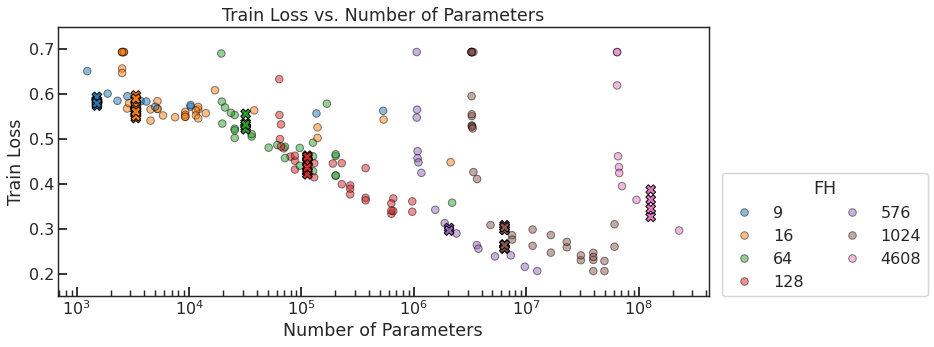

In [9]:
import copy 
final_epoch=10
# for final_epoch in [79]:
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})
# counts = _df.groupby("FH")["num_parameters"].transform("nunique") 
# _df_filtered = _df[counts >= 7]
# _df_filtered["num_hidden_features_mlp=FH"] = _df_filtered["num_hidden_features_mlp"] == _df_filtered["FH"]

# fig, ax = plt.subplots(1, 1, figsize=(10, 5)) 
# df["log_num_parameters"] = np.log10(df["num_parameters"])
# sns.lineplot(x="epoch", y="train_loss", data=df, hue="log_num_parameters", palette="turbo", errorbar=None)
# plt.title(f"Train Loss vs. Epoch")
# plt.xlabel("Epoch")
# plt.ylabel("Train Loss")
# plt.legend(loc=(1.1,0.1), title="Log10 Parameters")
# plt.show()
_df = pd.DataFrame(df)
savefigdir = "./figs/Figure4"
utils.ensure_dir(savefigdir)

_df.to_csv(f"{savefigdir}/train_loss_vs_num_parameters_memo_jan25_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample.csv", index=False)
_df = _df[_df["epoch"] == final_epoch] 
_df_filtered = _df
subset_df_hidden_features_mlp = 64
# _df = _df[_df["num_hidden_features_mlp"] >= subset_df_hidden_features_mlp]
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# 1. Draw lines only (no markers)
# FH values you want colored (everything else -> black)
special_fh = [9, 16, 64, 128, 576, 1024, 4608]

# all FH levels present (use your provided list, or: sorted(_df_filtered["FH"].unique()))
all_fh = [16, 128, 72, 2, 8192, 512, 8, 64, 9, 1024, 1, 576, 4608, 1449,
          140, 450, 56, 2576, 144, 256, 707, 800]

# start with black for everyone
pal = {int(fh): "black" for fh in all_fh}

# assign distinct colors to the special ones
colors = sns.color_palette("tab10", n_colors=len(special_fh))
pal.update({fh: c for fh, c in zip(special_fh, colors)})

_df_filtered["num_hidden_features_mlp=FH"] = _df_filtered["num_hidden_features_mlp"] == _df_filtered["FH"]
# 2. Add markers on top (separate for True/False)
_false = _df_filtered[~_df_filtered["num_hidden_features_mlp=FH"]]
_false = _false[_false["FH"].isin(special_fh)]
_true = _df_filtered[_df_filtered["num_hidden_features_mlp=FH"]]
 

sns.scatterplot(
    x="num_parameters", y="train_loss",
    hue="FH",
    data=_false,
    marker="o",
    s=60,
    edgecolor="black",
    linewidth=1,
    palette=pal,
    legend="full", alpha=0.5,
    ax=ax,
)

sns.scatterplot(
    x="num_parameters", y="train_loss",
    hue="FH",
    data=_true,
    marker="X",
    s=100,
    edgecolor="black",
    linewidth=1,
    palette=pal,
    legend=False,
    ax=ax,
)

# Add custom legend for markers
from matplotlib.lines import Line2D

ax.legend( 
        loc=(1.02, 0), title='FH', ncol=2)

ax.set_title(f"Train Loss vs. Number of Parameters")
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Train Loss")
ax.set_ylim(0.15, 0.75)
ax.set_xscale("log")

out = f"{savefigdir}/train_loss_vs_num_parameters"
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
# fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# # Show Recall accuracy vs num_heads and num_hidden_features
# # 1. Draw lines only (no markers)
# sns.lineplot(
#     x="num_parameters", y="test_accuracy",
#     hue="FH",
#     data=_df_filtered,
#     palette="tab10",
#     legend=False,
#     ax=ax,
# )

# # 2. Add markers on top (separate for True/False)
# _false = _df_filtered[~_df_filtered["num_hidden_features_mlp=FH"]]
# _true = _df_filtered[_df_filtered["num_hidden_features_mlp=FH"]]

# sns.scatterplot(
#     x="num_parameters", y="test_accuracy",
#     hue="FH",
#     data=_false,
#     marker="o",
#     s=60,
#     edgecolor="black",
#     linewidth=1,
#     palette="tab10",
#     legend="full",
#     ax=ax,
# )

# sns.scatterplot(
#     x="num_parameters", y="test_accuracy",
#     hue="FH",
#     data=_true,
#     marker="X",
#     s=100,
#     edgecolor="black",
#     linewidth=1,
#     palette="tab10",
#     legend=False,
#     ax=ax,
# )

# # Add custom legend for markers
# from matplotlib.lines import Line2D
# handles, labels = ax.get_legend_handles_labels()
# marker_legend = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
#         markersize=8, markeredgecolor='black', label='False'),
#     Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', 
#         markersize=10, markeredgecolor='black', label='True')
# ]
# ax.legend(handles=handles + marker_legend, 
#         labels=labels + ['False', 'True'],
#         loc=(1.02, 0), title='FH / Match')


# ax.set_title(f"Recall accuracy of Top 1000 sequences vs. FH (F=num_hidden_features, H=num_heads)\n \
#     num_hidden_features_mlp >= {subset_df_hidden_features_mlp}")
# ax.set_xlabel("Number of Parameters")
# ax.set_xscale("log")
# ax.set_ylabel("Recall accuracy")
# ax.set_xscale("log")
# plt.show()


# Figure 5: One layer model, show max rank (capacity), speed, and data switch experiments

For D=FH models, data switch experiments




In [1]:
import pickle 
from glob import glob 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import utils
from collections import defaultdict



/tmp/ipykernel_1690474/1761114762.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
folders = glob("/scratch/qanguyen/gautam/cache/memo_jan4_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/*")
df = defaultdict(list)
for folder in folders: 
    print(folder)
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    print(data.keys())
    if "logs" not in data:
        continue
    # if len(data['logs']) < 80: 
        # continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    print("len(data['logs'])", len(data["logs"]), "arch", data["args"]["arch"], "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"])
    
    logs = data["logs"][0]
    train_losses = [l["train_loss"] for l in data["logs"]] 
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"]
    accuracy = data["logs"][-1]["test_metrics"]["accuracy"].mean()
     
    df["train_loss"].extend(train_losses)
    df["test_accuracy"].extend([accuracy] * len(train_losses))
    df["num_parameters"].extend([num_parameters] * len(train_losses))
    df["num_hidden_features"].extend([num_hidden_features] * len(train_losses))
    df["num_heads"].extend([num_heads] * len(train_losses))
    df["epoch"].extend(range(len(train_losses)))
    # df = pd.read_csv(f"{folder}/eval_results.csv")
    # print(df.head())


/scratch/qanguyen/gautam/cache/memo_jan4_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan4_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_1_nheads_16_nlayers_1_1767540071.344091
dict_keys(['args', 'logs', 'model'])
len(data['logs']) 51 arch OneLayerAttention num_parameters 3362 num_layers 1 num_heads 16 num_hidden_features 1
/scratch/qanguyen/gautam/cache/memo_jan4_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan4_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_512_nheads_16_nlayers_1_1767565879.5156736
dict_keys(['sequences', 'switch_start_iter'])
/scratch/qanguyen/gautam/cache/memo_jan4_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample/memo_jan4_zipf_onelayerattention_vary_num_hidden_features_num_heads_noresample_transformer_K_100000_L_100_hidden_128_nheads_14_nlayers_1_1767556577.8595333
dict_keys(

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


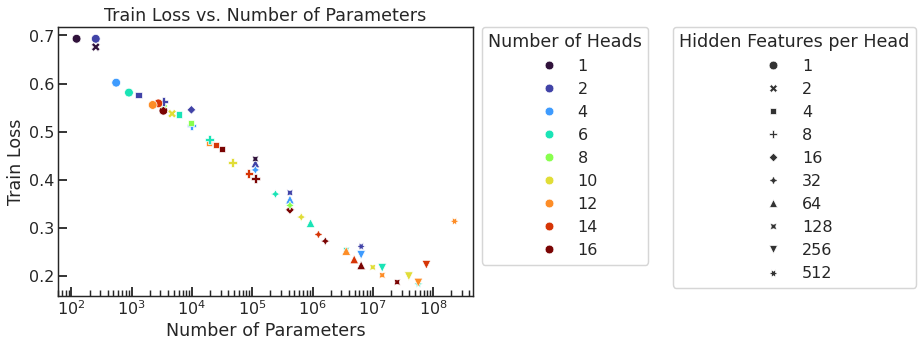

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


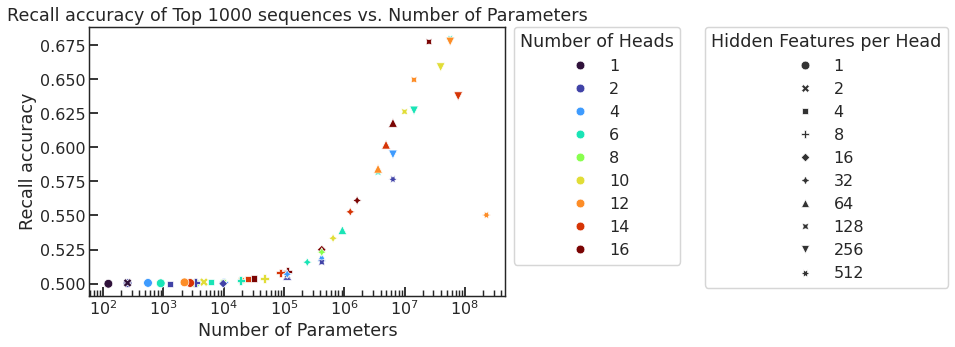

In [5]:
final_epoch=50
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})

_df = pd.DataFrame(df)
_df = _df[_df["epoch"] == final_epoch]
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

sns.scatterplot(
    x="num_parameters", y="train_loss",
    hue="num_heads",
    style="num_hidden_features",
    data=_df,
    palette="turbo",
    legend="full",
    ax=ax,
)

ax.set_title("Train Loss vs. Number of Parameters")
ax.set_xlabel("Number of Parameters")
ax.set_xscale("log")
ax.set_ylabel("Train Loss")

# grab seaborn's combined legend entries, then remove it
handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

# split at the "num_hidden_features" header
i = labels.index("num_hidden_features")
h_hue, l_hue = handles[1:i], labels[1:i]
h_style, l_style = handles[i+1:], labels[i+1:]

# make room on the right for TWO legend boxes
fig.subplots_adjust(right=0.62)

# legend 1 (left of the pair)
leg1 = ax.legend(
    h_hue, l_hue,
    title="Number of Heads",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)
ax.add_artist(leg1)

# legend 2 (to the right of legend 1)
ax.legend(
    h_style, l_style,
    title="Hidden Features per Head",
    loc="upper left",
    bbox_to_anchor=(1.48, 1.0),  # increase x to move further right
    borderaxespad=0.0,
)
savefigdir = "./figs/Figure5"
out = f"{savefigdir}/onelayer_train_loss_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
 
# Show Recall accuracy vs num_heads and num_hidden_features
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

sns.scatterplot(
    x="num_parameters", y="test_accuracy",
    hue="num_heads",
    style="num_hidden_features",
    data=_df,
    palette="turbo",
    legend="full",
    ax=ax,
)

ax.set_title("Recall accuracy of Top 1000 sequences vs. Number of Parameters")
ax.set_xlabel("Number of Parameters")
ax.set_xscale("log")
ax.set_ylabel("Recall accuracy")

# grab seaborn's combined legend entries, then remove it
handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

# split at the "num_hidden_features" header
i = labels.index("num_hidden_features")
h_hue, l_hue = handles[1:i], labels[1:i]
h_style, l_style = handles[i+1:], labels[i+1:]

# make room on the right for TWO legend boxes
fig.subplots_adjust(right=0.62)

# legend 1 (left of the pair)
leg1 = ax.legend(
    h_hue, l_hue,
    title="Number of Heads",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)
ax.add_artist(leg1)

# legend 2 (to the right of legend 1)
ax.legend(
    h_style, l_style,
    title="Hidden Features per Head",
    loc="upper left",
    bbox_to_anchor=(1.48, 1.0),  # increase x to move further right
    borderaxespad=0.0,
)
savefigdir = "./figs/Figure5"
out = f"{savefigdir}/onelayer_recall_accuracy_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(10, 5)) 
df["log_num_parameters"] = np.log10(df["num_parameters"])
sns.lineplot(x="epoch", y="train_loss", data=df, hue="log_num_parameters", palette="turbo", errorbar=None)
plt.title(f"Train Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.legend(loc=(1.1,0.1), title="Log10 Parameters")
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_heads", y="train_loss", hue = "num_hidden_features", data=_df, palette="turbo")
plt.title(f"Train Loss vs. Number of Heads")
plt.xlabel("Number of Heads")
# plt.xscale("log")
plt.ylabel("Train Loss")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_hidden_features", y="train_loss", hue="num_heads", data=_df, palette="turbo")
plt.title(f"Train Loss vs. Number of Hidden Features")
plt.xlabel("Number of Hidden Features")
# plt.xscale("log")
plt.ylabel("Train Loss")
plt.show()

# Test accuracy 
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_heads", y="test_accuracy", hue = "num_hidden_features", data=_df, palette="turbo")
plt.title(f"Test Accuracy vs. Number of Heads")
plt.xlabel("Number of Heads")
# plt.xscale("log")
plt.ylabel("Test Accuracy")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_hidden_features", y="test_accuracy", hue="num_heads", data=_df, palette="turbo")
plt.title(f"Test Accuracy vs. Number of Hidden Features")
plt.xlabel("Number of Hidden Features")
# plt.xscale("log")
plt.ylabel("Test Accuracy")
plt.show() 

## Appearances

In [6]:
folders = glob("/scratch/qanguyen/gautam/cache/memo_jan20_zipf_onelayerattention_vary_num_hidden_features_num_heads_doresample/*")
df = defaultdict(list)
for folder in folders:
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    if "logs" not in data:
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    print("len(data['logs'])", len(data["logs"]), "key", data["logs"][0].keys(), "arch", data["args"]["arch"], "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"])
    if num_parameters > 1e6 and data["logs"][-1]["train_loss"] > 0.3:
        continue
    if len(data["logs"]) < 10:
        continue
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"] 
    num_appearances_at_39 = None
    for l in data["logs"]:
        num_appearances = l["num_apppearances"][::10]
        
        test_metrics = l["test_metrics"]
        sequence_ranks = test_metrics["sequence_rank"] * 10
        accuracy = test_metrics["accuracy"] 
        # if num_appearances_at_39 is not None:
            # num_appearances -= num_appearances_at_39
        df["num_appearances"].extend(num_appearances)
        df["sequence_rank"].extend(sequence_ranks)
        df["accuracy"].extend(accuracy)
        df["num_parameters"].extend([ num_parameters ] * len(num_appearances))
        df["epoch"].extend([l["epoch"]] * len(num_appearances))  
        df["switch_number"].extend([int (l["epoch"] // (np.round(len(data["logs"]) / 2.0))+1.0)] * len(num_appearances))  
        if l["epoch"]  == 39: 
            num_appearances_at_39 = num_appearances
        if l["epoch"]  == 40:
            print(num_appearances) 

len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) arch OneLayerAttention num_parameters 1298 num_layers 1 num_heads 2 num_hidden_features 4
[0. 0. 0. ... 0. 0. 0.]
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) arch OneLayerAttention num_parameters 3626498 num_layers 1 num_heads 6 num_hidden_features 128
[0. 0. 0. ... 0. 0. 0.]
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) arch OneLayerAttention num_parameters 3362 num_layers 1 num_heads 2 num_hidden_features 8
[0. 0. 0. ... 0. 0. 0.]
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) arch OneLayerAttention num_parameters 25399298 num_layers 1 num_heads 16 num_hidden_features 

In [7]:
THRESHOLD = 0.9
_df = pd.DataFrame(df)
cols = ['num_appearances', 'sequence_rank', 'accuracy', 'num_parameters', 'epoch', 'num_appearances_at_saturation']
results = []
df_capacity = defaultdict(list)
for switch_number in _df["switch_number"].unique():
    for num_parameter in _df["num_parameters"].unique():
        # Filter by parameter count
        subdf = _df[np.abs(_df["num_parameters"] - num_parameter) < 1e-2].copy()
        subdf = subdf[subdf["switch_number"] == switch_number]
        # display(subdf)
        
        # 1. Identify which ranks ever reached the threshold
        ranks_that_met_90 = subdf.loc[subdf["accuracy"] > THRESHOLD, "sequence_rank"].unique()
        
        # 2. Extract rows for ranks that met 90% (get the MIN epoch where accuracy > 0.9)
        df_met = (
            subdf[(subdf["sequence_rank"].isin(ranks_that_met_90)) & (subdf["accuracy"] > THRESHOLD)]
            .sort_values("epoch", ascending=True)
            .drop_duplicates("sequence_rank")
        )
        # df_met["num_appearances_at_saturation"] = df_met["num_appearances"]
        assert "switch_number" in df_met, "df_met doesn't have switch_number"
        df_capacity["num_parameters"].extend([num_parameter])
        df_capacity["max_rank_at_saturation"].extend([df_met["sequence_rank"].max()])
        # display("num_parameter", num_parameter, "df_met", df_met)
        # 3. Extract rows for ranks that NEVER met 90% (get the MAX epoch available)
        # df_never_met = (
        #     subdf[~subdf["sequence_rank"].isin(ranks_that_met_90)]
        #     .sort_values("epoch", ascending=False)
        #     .drop_duplicates("sequence_rank")
        # )
        # df_never_met["num_appearances_at_saturation"] = 1e5
        # 4. Combine and filter for requested columns
        result_epochs = (
            pd.concat([df_met])
            .sort_values("sequence_rank")
        )
        results.append(result_epochs)

In [8]:
results = pd.concat(results)
display(results)
_df = pd.DataFrame(df)
display(_df)


,num_appearances,sequence_rank,accuracy,num_parameters,epoch,switch_number
10000,21219.0,0,0.989899,1298,1,1
29610000,20924.0,0,1.000000,3626498,1,1
820001,3887.0,10,0.979798,3626498,2,1
820002,2034.0,20,0.949495,3626498,2,1
29620003,1364.0,30,0.979798,3626498,2,1
...,...,...,...,...,...,...
34209204,11.0,92040,0.919192,14330882,60,2
34219220,6.0,92200,0.909091,14330882,61,2
34389275,13.0,92750,0.909091,14330882,78,2
34319333,8.0,93330,0.919192,14330882,71,2


,num_appearances,sequence_rank,accuracy,num_parameters,epoch,switch_number
0,0.0,0,0.494949,1298,0,1
1,0.0,10,0.434343,1298,0,1
2,0.0,20,0.535354,1298,0,1
3,0.0,30,0.616162,1298,0,1
4,0.0,40,0.484848,1298,0,1
...,...,...,...,...,...,...
36799995,6.0,99950,0.494949,66242,79,2
36799996,9.0,99960,0.494949,66242,79,2
36799997,14.0,99970,0.525253,66242,79,2
36799998,9.0,99980,0.494949,66242,79,2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


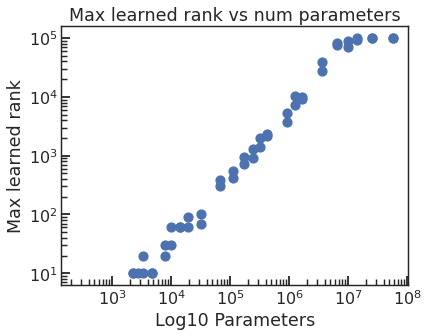

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


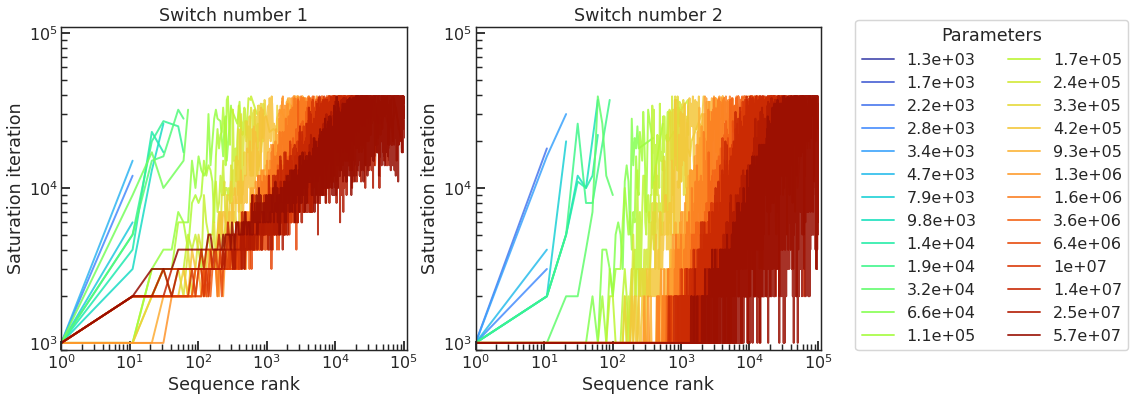

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


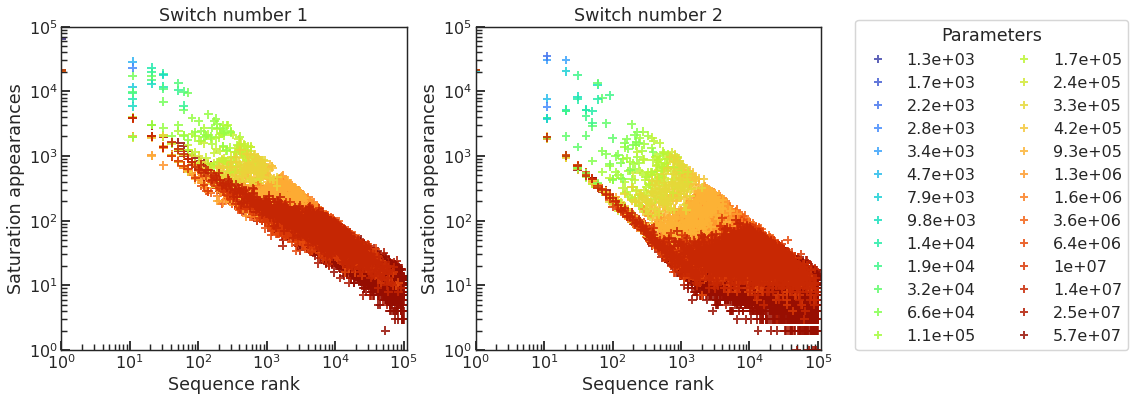

In [12]:
# plot the max rank at saturation vs num parameters
plt.scatter(df_capacity["num_parameters"], df_capacity["max_rank_at_saturation"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Log10 Parameters")
plt.ylabel("Max learned rank")
plt.title("Max learned rank vs num parameters")
out = f"{savefigdir}/onelayer_max_rank_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# plot the saturation time vs sequence rank
def compute_saturation_time(row):
    time = row["epoch"] 
    if row["switch_number"] == 1:
        return time * 1000
    else:
        return (time - (row["switch_number"] - 1) * 40) * 1000

results["iters"] = results.apply(compute_saturation_time, axis=1)
results["sequence_rank_plus_one"] = results["sequence_rank"] + 1

# 2 significant figures for legend labels
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, switch_number in enumerate(results["switch_number"].unique()):
    subresults = results[results["switch_number"] == switch_number]
    order = np.sort(subresults["num_parameters"].unique())
    pal = sns.color_palette("turbo", n_colors=len(order))
    sns.lineplot(
        data=subresults,
        x="sequence_rank_plus_one",
        y="iters",
        hue="num_parameters",           # <-- use formatted labels  
        hue_order=order,              # <-- numeric ascending -> consistent color order
        palette=pal,
        linewidth=2.0,
        alpha=0.85,
        legend=False if i == 0 else True,
        ax=axs[i]
    )
    axs[i].set_title(f"Switch number {switch_number}")
    axs[i].set_xscale("log")
    axs[i].set_xlim(1, 110000)
    axs[i].set_ylim(900, 110000)
    axs[i].set_yscale("log")
    axs[i].set_xlabel("Sequence rank")
    axs[i].set_ylabel("Saturation iteration")

handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(
    handles=handles[1:],
    labels=[f"{float(l):.2g}" for l in labels[1:]],
    title="Parameters",
    loc=(1.1, 0.0), ncol=2
)
out = f"{savefigdir}/onelayer_saturation_time_vs_sequence_rank"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, switch_number in enumerate(results["switch_number"].unique()):
    subresults = results[results["switch_number"] == switch_number]
    order = np.sort(subresults["num_parameters"].unique())
    pal = sns.color_palette("turbo", n_colors=len(order))
    sns.scatterplot(
        data=subresults,
        x="sequence_rank_plus_one",
        y="num_appearances",
        hue="num_parameters",
        hue_order=order,
        palette=pal,
        linewidth=2.0,
        alpha=0.85,
        legend=False if i == 0 else True,
        marker="+",
        ax=axs[i]
    )
    axs[i].set_title(f"Switch number {switch_number}")
    axs[i].set_xscale("log")
    axs[i].set_xlim(1, 110000)
    axs[i].set_ylim(1, 100000)
    axs[i].set_yscale("log")
    axs[i].set_xlabel("Sequence rank")
    axs[i].set_ylabel("Saturation appearances")

handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(
    handles=handles[1:],
    labels=[f"{float(l):.2g}" for l in labels[1:]],
    title="Parameters",
    loc=(1.1, 0.0), ncol=2
)
out = f"{savefigdir}/onelayer_saturation_appearances_vs_sequence_rank"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Data switch

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


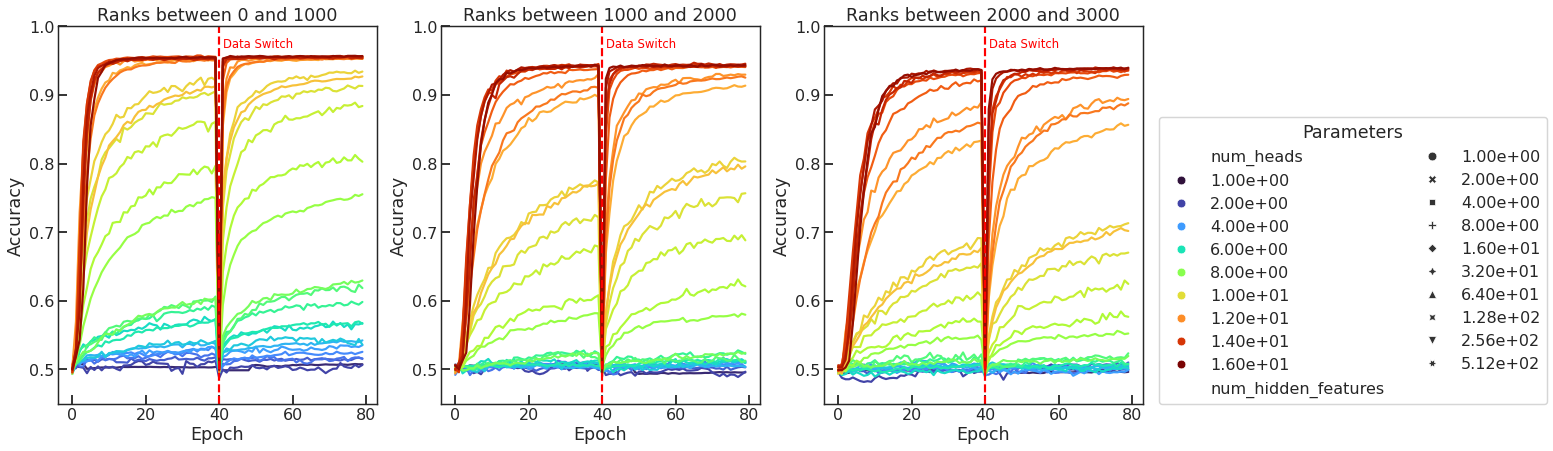

In [ ]:
batch = 1000
order = np.sort(_df["num_parameters"].unique())
pal = sns.color_palette("turbo", n_colors=len(order))
fig, axs = plt.subplots(1,3, figsize=(20, 7))
for i in range(3):
    _df["true_num_parameters"] = _df["num_parameters"].astype(float)
    
    # 1. Capture the axis object from lineplot
    sns.lineplot(
        data=_df[(_df['sequence_rank'] <= batch*(i+1)) & (_df['sequence_rank'] >= batch*i)], 
        x="epoch", y="accuracy", 
        hue="true_num_parameters", palette=pal, errorbar=None, 
        ax=axs[i],
        legend="full" if i == 2 else False
    ) 
    
    # 2. Get handles and current labels
    handles, labels = ax.get_legend_handles_labels()
    
    # 3. Format labels to 2 decimal places (handling the title label if it exists)
    formatted_labels = []
    for label in labels:
        try:
            formatted_labels.append(f"{float(label):.2e}")
        except ValueError:
            formatted_labels.append(label) # Keep the 'num_parameters' title as is
            
    # 4. Re-apply the legend with formatted labels
    if i == 2: 
        axs[i].legend(handles=handles, labels=formatted_labels, ncol=2, loc=(1.05, 0), title="Parameters")
    axs[i].axvline(x=40, color='red', linestyle='--')
    axs[i].text(41, 0.969, "Data Switch", color='red', fontsize=12)
    axs[i].set_title(f"Ranks between {batch*i} and {batch*(i+1)}")
    axs[i].set_xlabel("Epoch")
    axs[i].set_ylabel("Accuracy")
    axs[i].set_ylim(0.45, 1.0)

out = f"{savefigdir}/onelayer_data_switch_accuracy"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Figure 6: Rescue experiments with 1 layer model 


In [17]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import utils
from collections import defaultdict
from glob import glob
# fname = './cache/memo_may10_zipf_onelayerattention_lr_1e-3/memo_may10_zipf_onelayerattention_lr_1e-3_transformer_K_1000_L_100_hidden_8_nheads_20_nlayers_4_1746999806.3694336/memo_may10_zipf_onelayerattention_lr_1e-3_transformer_K_1000_L_100_hidden_8_nheads_20_nlayers_4_1746999806.3694336.pkl' 
# f = './cache/memo_june28_fork_progress/*'
f = '/scratch/qanguyen/gautam/cache/memo_jan2_fork_progress_freeze_all_attn_weights_K_100000/*'
df = defaultdict(list)
folders = glob(f) 
print(len(folders))
for folder in folders:
    
    subdir = folder.split('/')[-1]
    fname = folder + '/' + subdir + '.pkl'
    try:
        with open(fname, 
                'rb') as f:
            data = utils.CPU_Unpickler(f).load()
        
    except Exception as e:
        continue
    # print("args", data["args"]["num_mlp_layers"], [l["train_loss"] for l in data["logs"]])
    print(data.keys())
    # plot train loss
    # fig, axs = plt.subplots(1, 1, figsize=(5, 6))
    # num_iters_per_epoch = 1000
    # axs.plot(np.arange(0,len(data["logs"])*num_iters_per_epoch,num_iters_per_epoch), [i["train_loss"] for i in data["logs"]])
    model = data["model"]
    
    
    num_heads = data["args"]["num_heads"]
    num_hidden_features = data["args"]["num_hidden_features"]   
    print("model", data["args"]["lr"], num_heads, num_hidden_features, np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()]), 
          "len logs", len(data["logs"]), "epochs", (data["logs"][-1]["epoch"]+1)*50, 
          "is_resample_tasks", data["args"]["is_resample_tasks"]) 
    if (data["logs"][-1]["epoch"]+1)*50 < 2000: 
        continue
    
    # Too few iterations, skip
    # if (data["logs"][-1]["epoch"]+1)*50 < 20000: 
        # continue
    logsoftmaxloss = defaultdict(list)
    K = data["args"]["K"]
    pre_switch_last_log = len(data["logs"]) // 2 - 1 
    post_switch_last_log = len(data["logs"]) - 1 
    last_log = data["logs"][-1]
    # last_accuracy = last_log["test_metrics"]["accuracy"][:10000].mean()
    # print(last_log["test_metrics"]["accuracy"][9990:10010])
    train_losses = [l["train_loss"] for l in data["logs"]] 
    # plt.plot(train_losses)
    # plt.title(f"num_params {np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()])}")
    # plt.show()
    # spacing = 10
    # df_num_appearances = defaultdict(list)
    # print(len(data["logs"]))
    for log_id, l in enumerate(data["logs"]): 
        if "probe_metrics" in l:
            # print(np.stack(l["probe_metrics"]["accuracy"]).flatten())
            df["num_iters_required"].append(l["probe_metrics"]["num_iters_required"]) 
            df["num_heads"].append(num_heads)
            df["num_hidden_features"].append(num_hidden_features)
            df["num_parameters"].append(np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()]))
            # df["last_accuracy"].append(last_accuracy)
            df["probe_accuracy"].append(np.stack(l["probe_metrics"]["accuracy"]).flatten()[-10:].mean())
            df["train_loss"].append(l["train_loss"])
            # df["pre_switch_last_accuracy"].append(data["logs"][pre_switch_last_log]["test_metrics"]["accuracy"][:10000].mean())
            # df["pre_switch_last_train_loss"].append(data["logs"][pre_switch_last_log]["train_loss"]) 
            df["num_params"].append(np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()]))
            df["learning_rate"].append(data["args"]["lr"])
            df["iteration"].append((l["epoch"]+1)*50) # number of iterations 
            # plt.plot(np.stack(l["probe_metrics"]["accuracy"]).flatten())
            # plt.xlabel("Probe iteration")
            # plt.ylabel("Probe accuracy")
            # plt.title(f"Probe accuracy for num_parameters={np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()])}, num_heads={num_heads}, num_hidden_features={num_hidden_features}, iter={l['epoch']*50}")
            # plt.legend()
            # plt.show()


0


In [18]:
# plot a heat map of the num_iters_required vs num_heads and num_hidden_features
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})
df_num_iters_required = pd.DataFrame(df)
_df_num_iters_required = df_num_iters_required.pivot_table(index="num_parameters", columns="iteration", values="probe_accuracy", aggfunc="mean")
sns.heatmap(_df_num_iters_required, annot=False, cmap="YlGnBu")
plt.title("Probe accuracy vs. num parameters and iteration")
plt.xlabel("Epoch")
# plt.ylabel("Number of parameters")
# draw a vertical line at iteration 40000
plt.axvline(x=40000, color='red', linestyle='--', label='Iteration 40000')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
_df = df_num_iters_required[df_num_iters_required["iteration"].isin([50, 100, 250, 500, 2000])]
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.lineplot(x="num_parameters", y="probe_accuracy", data=_df, 
            hue="iteration", palette="turbo",
            marker="o", markersize=3)
plt.xscale("log")
plt.title("Probe accuracy vs. num parameters at Iteration 1000")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
_df = pd.DataFrame(df)
vals = np.sort(_df["num_parameters"].unique().astype(float))
idx = np.unique(np.round(np.linspace(0, len(vals)-1, 5)).astype(int))
keep = vals[idx]

df5 = _df[_df["num_parameters"].astype(float).isin(keep)]


sns.lineplot(x="iteration", y="probe_accuracy", data=df5, 
            hue="num_parameters", 
            palette="tab10",
            # marker="o", 
            markersize=10)
# plt.xscale("log")
plt.title("Probe accuracy vs. Training iteration")
plt.xlabel("Training iteration")
plt.ylabel("Probe accuracy")
# 2. Get handles and current labels
handles, labels = ax.get_legend_handles_labels()

# 3. Format labels to 2 decimal places (handling the title label if it exists)


formatted_labels = []
for label in labels:
    try:
        formatted_labels.append(f"{float(label):.2e}")  # e.g. 1.35e+06
        # or: formatted_labels.append(f"{float(label):.2g}")  # 2 sig figs, auto
    except ValueError:
        formatted_labels.append(label)
# 4. Re-apply the legend with formatted labels
plt.legend(handles=handles, labels=formatted_labels, 
    title = "Number of Parameters", ncol=2, loc=(1.05, 0))
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.lineplot(x="iteration", y="num_iters_required", data=df5, 
            hue="num_parameters", 
            palette="tab10",
            # marker="o", 
            markersize=10)
# plt.xscale("log")
plt.title("Number of probe iterations required vs. Train iteration")
plt.xlabel("Training iteration")
plt.ylabel("Number of iterations required")
# 2. Get handles and current labels
handles, labels = ax.get_legend_handles_labels()

# 3. Format labels to 2 decimal places (handling the title label if it exists)


formatted_labels = []
for label in labels:
    try:
        formatted_labels.append(f"{float(label):.2e}")  # e.g. 1.35e+06
        # or: formatted_labels.append(f"{float(label):.2g}")  # 2 sig figs, auto
    except ValueError:
        formatted_labels.append(label)
# 4. Re-apply the legend with formatted labels
plt.legend(handles=handles, labels=formatted_labels, 
    title = "Number of Parameters", ncol=2, loc=(1.05, 0))
plt.show()


_df_num_iters_required = df_num_iters_required.pivot_table(index="num_parameters", columns="iteration", values="num_iters_required", aggfunc="mean")
sns.heatmap(_df_num_iters_required, annot=False, cmap="YlGnBu")
plt.axvline(x=40000, color='red', linestyle='--', label='Iteration 40000')
plt.title("Number of iterations required vs. num parameters and iteration")
plt.xlabel("Epoch")
plt.ylabel("Number of parameters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

_df_num_iters_required = df_num_iters_required[df_num_iters_required["iteration"].isin([50, 100, 250, 500, 2000])]
sns.lineplot(x="num_parameters", y="num_iters_required", data=_df_num_iters_required,
            palette="turbo",
            marker="o", markersize=3, hue="iteration")
plt.xscale("log")
plt.title("Number of iterations required vs. num parameters at Iteration 1000")
plt.show()
# Plot train accuracy vs. num parameters and iteration
df_train_accuracy = pd.DataFrame(df)

_df_train_accuracy = df_train_accuracy.pivot_table(index="num_parameters", columns="iteration", values="train_loss", aggfunc="mean")
sns.heatmap(_df_train_accuracy, annot=False, cmap="YlGnBu", vmin=0, vmax=1)
plt.axvline(x=40000, color='red', linestyle='--', label='Iteration 40000')
plt.title("Train accuracy vs. num parameters and iteration")
plt.xlabel("Epoch")
plt.ylabel("Number of parameters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'probe_accuracy'

## Supplementary Figure 6: Zero attention weights

In [19]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import utils
from collections import defaultdict
from glob import glob
# fname = './cache/memo_may10_zipf_onelayerattention_lr_1e-3/memo_may10_zipf_onelayerattention_lr_1e-3_transformer_K_1000_L_100_hidden_8_nheads_20_nlayers_4_1746999806.3694336/memo_may10_zipf_onelayerattention_lr_1e-3_transformer_K_1000_L_100_hidden_8_nheads_20_nlayers_4_1746999806.3694336.pkl' 
# f = './cache/memo_june28_fork_progress/*'
f = '/scratch/qanguyen/gautam/cache/memo_jan4_fork_progress_set_zero_all_attn_allow_learning_K_100000/*'
df = defaultdict(list)
folders = glob(f) 
print(len(folders))
for folder in folders:
    
    subdir = folder.split('/')[-1]
    fname = folder + '/' + subdir + '.pkl'
    try:
        with open(fname, 
                'rb') as f:
            data = utils.CPU_Unpickler(f).load()
        
    except Exception as e:
        continue
    print("args", data["args"]["num_mlp_layers"], "arch", data["args"]["arch"], "is_initialize_attention_weights_to_zero", data["args"]["is_initialize_attention_weights_to_zero"])
    print(data.keys())
    # plot train loss
    # fig, axs = plt.subplots(1, 1, figsize=(5, 6))
    # num_iters_per_epoch = 1000
    # axs.plot(np.arange(0,len(data["logs"])*num_iters_per_epoch,num_iters_per_epoch), [i["train_loss"] for i in data["logs"]])
    model = data["model"] 
    print(model.keys()) 
    for k in model.keys(): 
        if ("attn" in k):
            print(k, model[k]) 
    
    
    num_heads = data["args"]["num_heads"]
    num_hidden_features = data["args"]["num_hidden_features"]   
    print("model", data["args"]["lr"], num_heads, num_hidden_features, np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()]), 
          "len logs", len(data["logs"]), "epochs", (data["logs"][-1]["epoch"]+1)*50, 
          "is_resample_tasks", data["args"]["is_resample_tasks"]) 
    if (data["logs"][-1]["epoch"]+1)*50 < 2000: 
        continue
    
    # Too few iterations, skip
    # if (data["logs"][-1]["epoch"]+1)*50 < 20000: 
        # continue
    logsoftmaxloss = defaultdict(list)
    K = data["args"]["K"]
    pre_switch_last_log = len(data["logs"]) // 2 - 1 
    post_switch_last_log = len(data["logs"]) - 1 
    last_log = data["logs"][-1]
    # last_accuracy = last_log["test_metrics"]["accuracy"][:10000].mean()
    # print(last_log["test_metrics"]["accuracy"][9990:10010])
    train_losses = [l["train_loss"] for l in data["logs"]] 
    # plt.plot(train_losses)
    # plt.title(f"num_params {np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()])}")
    # plt.show()
    # spacing = 10
    # df_num_appearances = defaultdict(list)
    # print(len(data["logs"]))
    for log_id, l in enumerate(data["logs"]): 
        if "probe_metrics" in l:
            # print(np.stack(l["probe_metrics"]["accuracy"]).flatten())
            df["num_iters_required"].append(l["probe_metrics"]["num_iters_required"]) 
            df["num_heads"].append(num_heads)
            df["num_hidden_features"].append(num_hidden_features)
            df["num_parameters"].append(np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()]))
            # df["last_accuracy"].append(last_accuracy)
            df["probe_accuracy"].append(np.stack(l["probe_metrics"]["accuracy"]).flatten()[-10:].mean())
            df["train_loss"].append(l["train_loss"])
            # df["pre_switch_last_accuracy"].append(data["logs"][pre_switch_last_log]["test_metrics"]["accuracy"][:10000].mean())
            # df["pre_switch_last_train_loss"].append(data["logs"][pre_switch_last_log]["train_loss"]) 
            df["num_params"].append(np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()]))
            df["learning_rate"].append(data["args"]["lr"])
            df["iteration"].append((l["epoch"]+1)*50) # number of iterations 
            # plt.plot(np.stack(l["probe_metrics"]["accuracy"]).flatten())
            # plt.xlabel("Probe iteration")
            # plt.ylabel("Probe accuracy")
            # plt.title(f"Probe accuracy for num_parameters={np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in model.items()])}, num_heads={num_heads}, num_hidden_features={num_hidden_features}, iter={l['epoch']*50}")
            # plt.legend()
            # plt.show()


19
args 3 arch OneLayerAttention is_initialize_attention_weights_to_zero zero_all_attn_allow_learning
dict_keys(['args', 'logs', 'model'])
odict_keys(['wte.weight', 'wpe.weight', 'pre_attn_ln.weight', 'pre_attn_ln.bias', 'ln_f.weight', 'ln_f.bias', 'c_attn.weight', 'c_attn.bias', 'linear_modules.0.weight', 'linear_modules.0.bias', 'linear_modules.1.weight', 'linear_modules.1.bias', 'linear_modules.2.weight', 'linear_modules.2.bias', 'lm_head.weight', 'lm_head.bias'])
pre_attn_ln.weight tensor([1., 1., 1.,  ..., 1., 1., 1.])
pre_attn_ln.bias tensor([0., 0., 0.,  ..., 0., 0., 0.])
c_attn.weight tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0265, -0.0217,  0.0033,  ...,  0.0030, -0.0190,  0.0452],
        [-0.0038, -0.0038, -0.0196,  ...,  0.0087,  0.0008,  0.0255],
        [ 0.0163,  0.0045, -0.0252,  

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


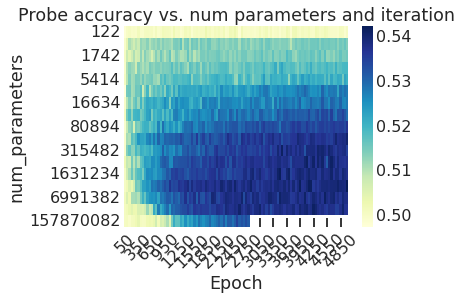

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


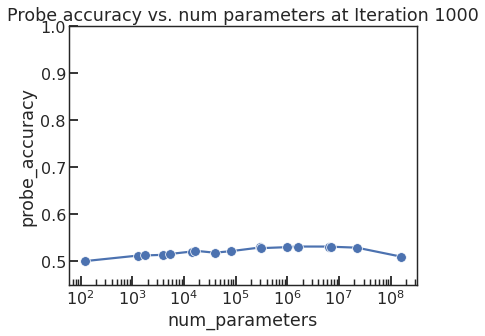

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


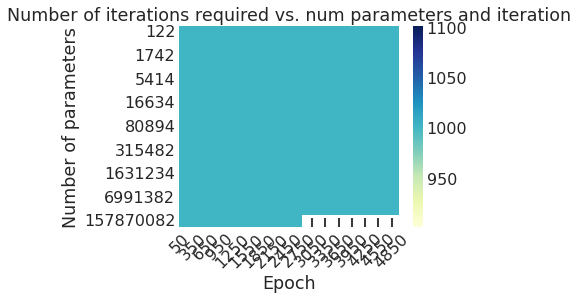

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


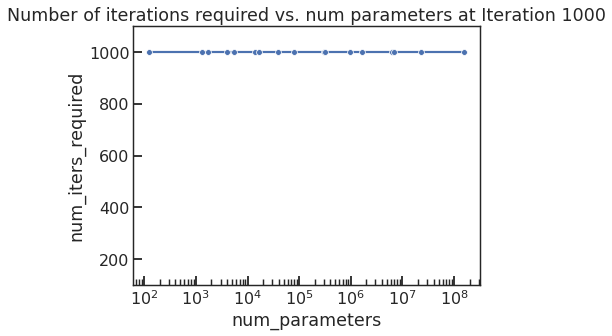

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


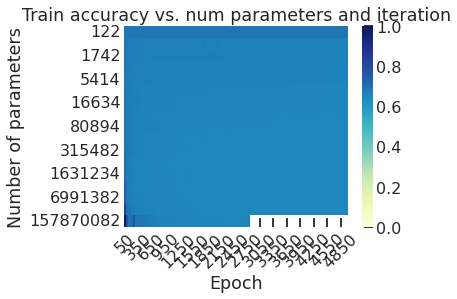

In [21]:
# plot a heat map of the num_iters_required vs num_heads and num_hidden_features
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})
df_num_iters_required = pd.DataFrame(df)
_df_num_iters_required = df_num_iters_required.pivot_table(index="num_parameters", columns="iteration", values="probe_accuracy", aggfunc="mean")
sns.heatmap(_df_num_iters_required, annot=False, cmap="YlGnBu")
plt.title("Probe accuracy vs. num parameters and iteration")
plt.xlabel("Epoch")
# plt.ylabel("Number of parameters")
# draw a vertical line at iteration 40000
plt.axvline(x=40000, color='red', linestyle='--', label='Iteration 40000')
plt.xticks(rotation=45)
plt.tight_layout()
savefigdir = "./figs/SupplementaryFigure6"
out = f"{savefigdir}/probe_accuracy_vs_num_parameters_and_iteration_zero_attn_weights"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
_df_num_iters_required = df_num_iters_required[df_num_iters_required["iteration"] == 1000]
sns.lineplot(x="num_parameters", y="probe_accuracy", data=_df_num_iters_required,
            marker="o", markersize=10)
plt.xscale("log")
plt.ylim(0.45, 1)
plt.title("Probe accuracy vs. num parameters at Iteration 1000")
savefigdir = "./figs/SupplementaryFigure6"
out = f"{savefigdir}/probe_accuracy_vs_num_parameters_at_iteration_1000_zero_attn_weights"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

_df_num_iters_required = df_num_iters_required.pivot_table(index="num_parameters", columns="iteration", values="num_iters_required", aggfunc="mean")
sns.heatmap(_df_num_iters_required, annot=False, cmap="YlGnBu")
plt.axvline(x=40000, color='red', linestyle='--', label='Iteration 40000')
plt.title("Number of iterations required vs. num parameters and iteration")
plt.xlabel("Epoch")
plt.ylabel("Number of parameters")
plt.xticks(rotation=45)
plt.tight_layout()
savefigdir = "./figs/SupplementaryFigure6"
out = f"{savefigdir}/num_iterations_required_vs_num_parameters_and_iteration_zero_attn_weights"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

_df_num_iters_required = df_num_iters_required[df_num_iters_required["iteration"] == 1000]
sns.lineplot(x="num_parameters", y="num_iters_required", data=_df_num_iters_required,
            marker="o", markersize=6)
plt.xscale("log")
plt.title("Number of iterations required vs. num parameters at Iteration 1000")
plt.ylim(100, 1100)
savefigdir = "./figs/SupplementaryFigure6"
out = f"{savefigdir}/num_iterations_required_vs_num_parameters_at_iteration_1000_zero_attn_weights"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
# Plot train accuracy vs. num parameters and iteration
df_train_accuracy = pd.DataFrame(df)

_df_train_accuracy = df_train_accuracy.pivot_table(index="num_parameters", columns="iteration", values="train_loss", aggfunc="mean")
sns.heatmap(_df_train_accuracy, annot=False, cmap="YlGnBu", vmin=0, vmax=1)
plt.axvline(x=40000, color='red', linestyle='--', label='Iteration 40000')
plt.title("Train accuracy vs. num parameters and iteration")
plt.xlabel("Epoch")
plt.ylabel("Number of parameters")
plt.xticks(rotation=45)
plt.tight_layout()
savefigdir = "./figs/SupplementaryFigure6"
out = f"{savefigdir}/train_accuracy_vs_num_parameters_and_iteration_zero_attn_weights"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()